# Description
This script compares cest values of regions within network vs between network.


## Import Packages

In [2]:
import os
import glob
import numpy as np
import pandas as pd
#import network_fcon as fc
import scipy as sp
from scipy.stats import pearsonr
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt
import re
import seaborn as sns
import statsmodels.formula.api as smf
from netneurotools import datasets, plotting

### Set Variables and Paths

In [11]:
# Set Variables
dataset = 'longglucest_outputmeasures2'
#atlas = 'Schaefer2018_1000Parcels_17Networks'
atlas = 'atl-Cammoun2012_res-500'
inpath = "/Users/pecsok/Desktop/ImageData/PMACS_remote/data/nmaps/analyses/" + atlas
outpath_box = '/Users/pecsok/Library/CloudStorage/Box-Box/GluCEST PhD/Manuscripts/Neuromaps/Results'
#nmaps = ["NMDA", "mGluR5", "GABA"]
nmaps = ["NMDA_avg", "mGluR5_avg", "GABA_avg","CB1"]
lobes = ['frontal','parietal','occipital']

# Import Data
means_df = pd.read_csv(inpath + '/means_std_normalized_cest_' + dataset + '_' + atlas + '.csv')
#means_df = pd.read_csv(inpath + '/means_subjectnmaps_' + dataset + '_' + atlas + '.csv')
means_df

# Add CB1
receptor_df = pd.read_csv("/Users/pecsok/projects/Neuromaps/pecsok_pfns/neuromaps/results/receptor_data_cammoun2012_scale500.csv", sep=',')

means_df = means_df.merge(receptor_df[['Parcel', 'CB1']], on='Parcel', how='left')


In [8]:
print(means_df)

                         Parcel hstatus  CEST_avg  NMDA_avg  mGluR5_avg  \
0    caudalanteriorcingulate_5R      HC  0.140048 -0.026330    1.229935   
1    caudalanteriorcingulate_5R     PSY -0.011085 -0.026330    1.229935   
2                     cuneus_3R      HC  0.884299 -0.522157    0.053661   
3                     cuneus_3R     PSY  0.305783 -0.522157    0.053661   
4                     cuneus_5R      HC  1.411665  0.046650    0.220775   
..                          ...     ...       ...       ...         ...   
99           superiorfrontal_7R     PSY -0.455633  0.739121    1.834678   
100          superiorfrontal_8R      HC -0.857712 -0.331275   -0.129873   
101          superiorfrontal_8R     PSY -0.800876 -0.331275   -0.129873   
102          superiorfrontal_9R      HC -0.154002 -0.293822   -0.660154   
103          superiorfrontal_9R     PSY -0.372532 -0.293822   -0.660154   

     GABA_avg       Lobe       CB1  
0   -0.473436    frontal  1.466086  
1   -0.473436    frontal 

### NMAP correlations

In [12]:
if atlas == 'atl-Cammoun2012_res-500':
    # List of subcortical parcels
    subcortical = ['accumbensarea NZMean', 'brainstem NZMean', 'thalamusproper NZMean']  # Replace with actual subcortical parcel names
    means_df_sub = means_df[means_df['Parcel'].isin(subcortical)]
    means_df_cort = means_df[~means_df['Parcel'].isin(subcortical)]  
means_df = means_df_cort

                         Parcel hstatus  CEST_avg  NMDA_avg  mGluR5_avg  \
0    caudalanteriorcingulate_5R      HC  0.140048 -0.026330    1.229935   
1    caudalanteriorcingulate_5R     PSY -0.011085 -0.026330    1.229935   
2                     cuneus_3R      HC  0.884299 -0.522157    0.053661   
3                     cuneus_3R     PSY  0.305783 -0.522157    0.053661   
4                     cuneus_5R      HC  1.411665  0.046650    0.220775   
..                          ...     ...       ...       ...         ...   
99           superiorfrontal_7R     PSY -0.455633  0.739121    1.834678   
100          superiorfrontal_8R      HC -0.857712 -0.331275   -0.129873   
101          superiorfrontal_8R     PSY -0.800876 -0.331275   -0.129873   
102          superiorfrontal_9R      HC -0.154002 -0.293822   -0.660154   
103          superiorfrontal_9R     PSY -0.372532 -0.293822   -0.660154   

     GABA_avg       Lobe       CB1  
0   -0.473436    frontal  1.466086  
1   -0.473436    frontal 

/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_89803/54851465.py:32: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=nmap, y='CEST_avg', data=graph_df, #color="dimgray", #hue='hstatus',


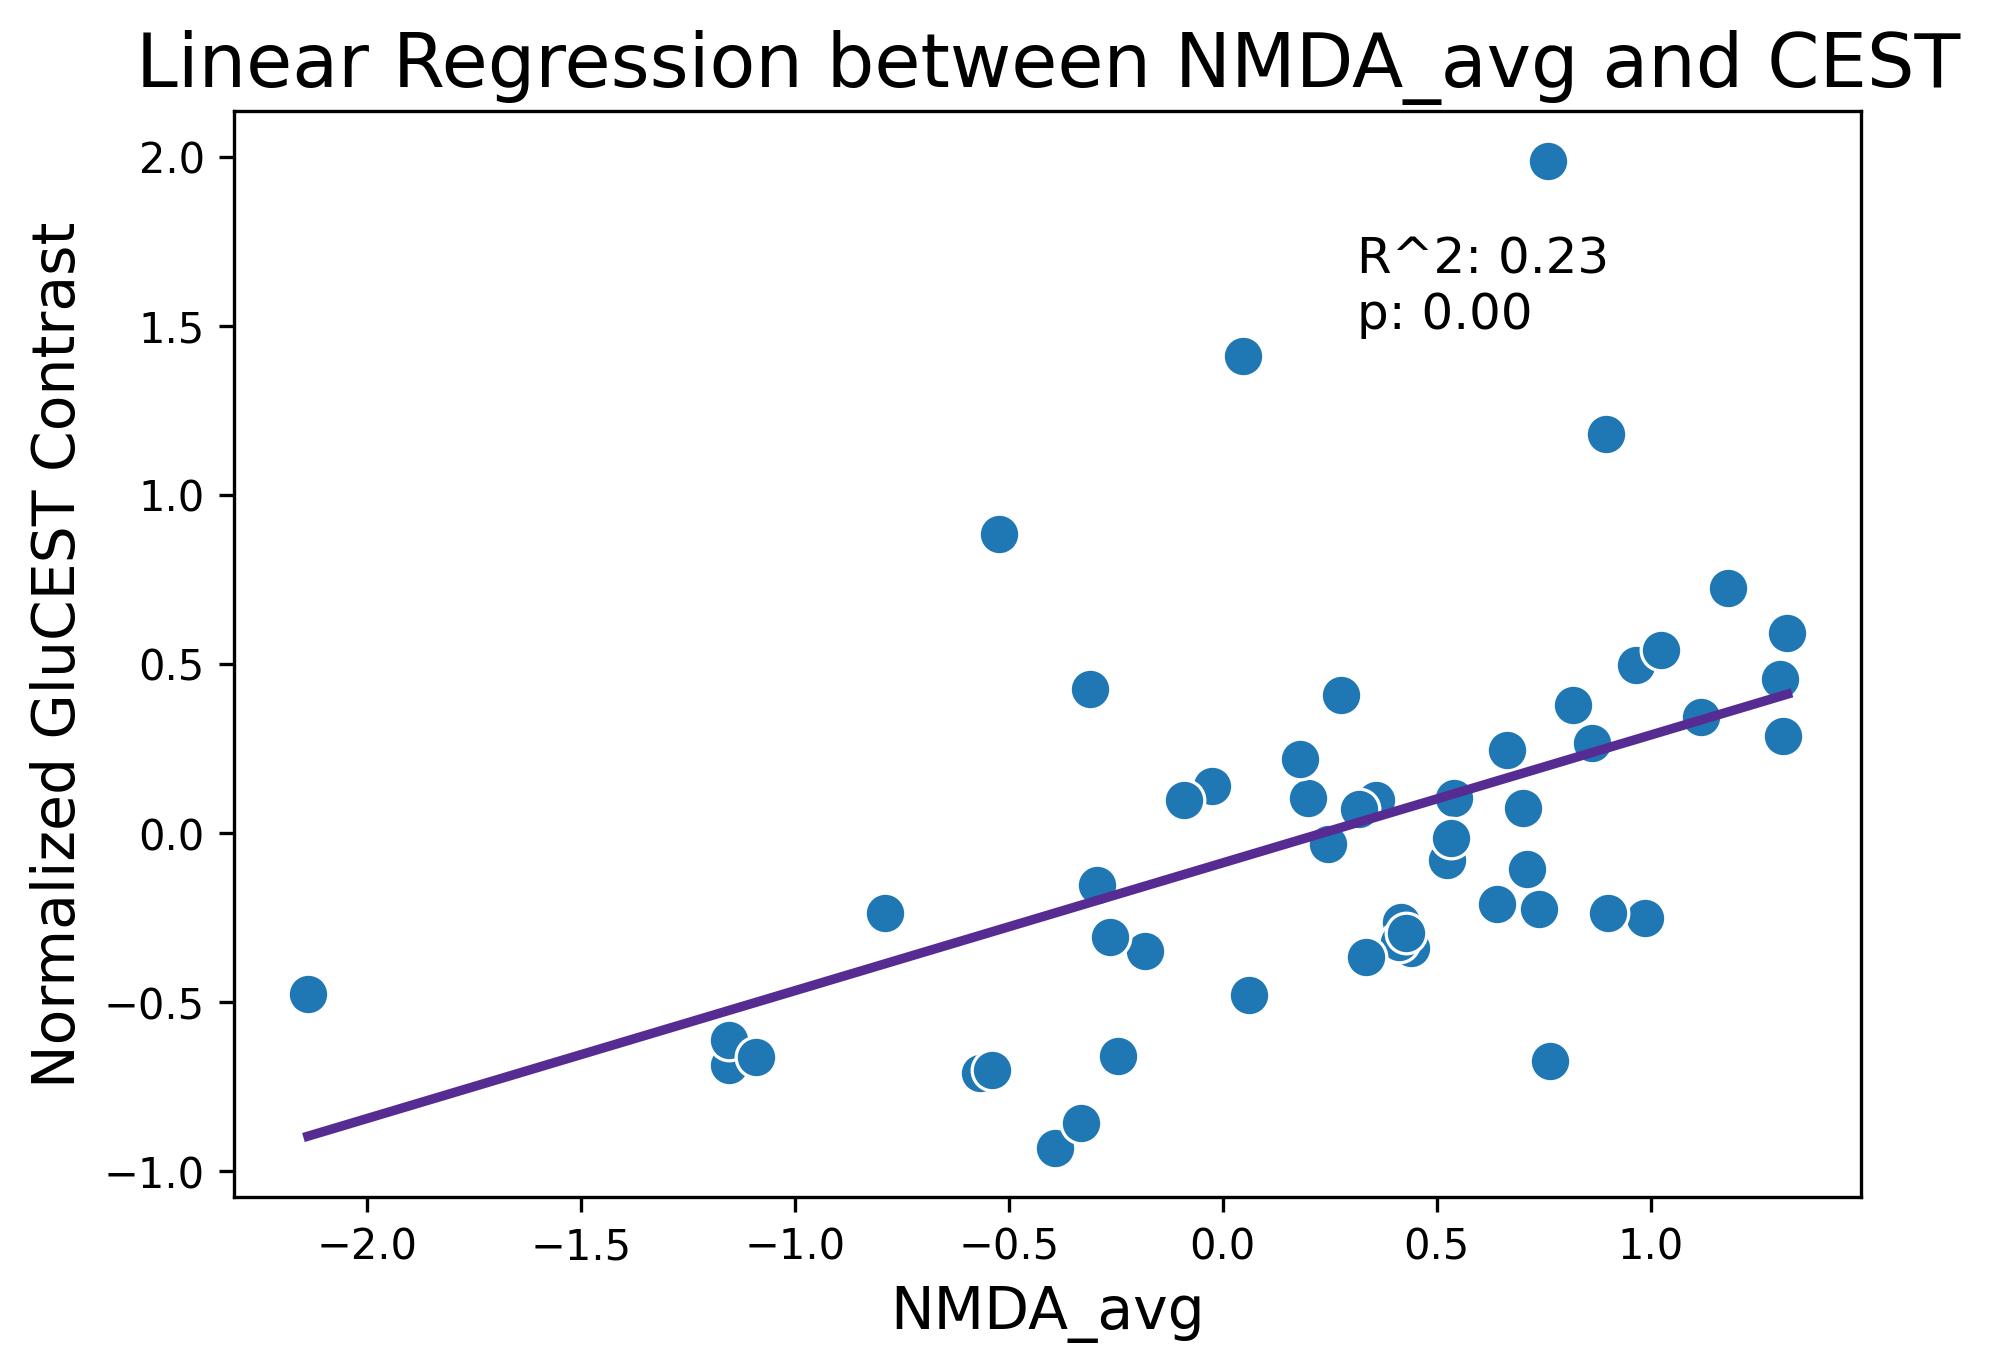

/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_89803/54851465.py:32: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=nmap, y='CEST_avg', data=graph_df, #color="dimgray", #hue='hstatus',


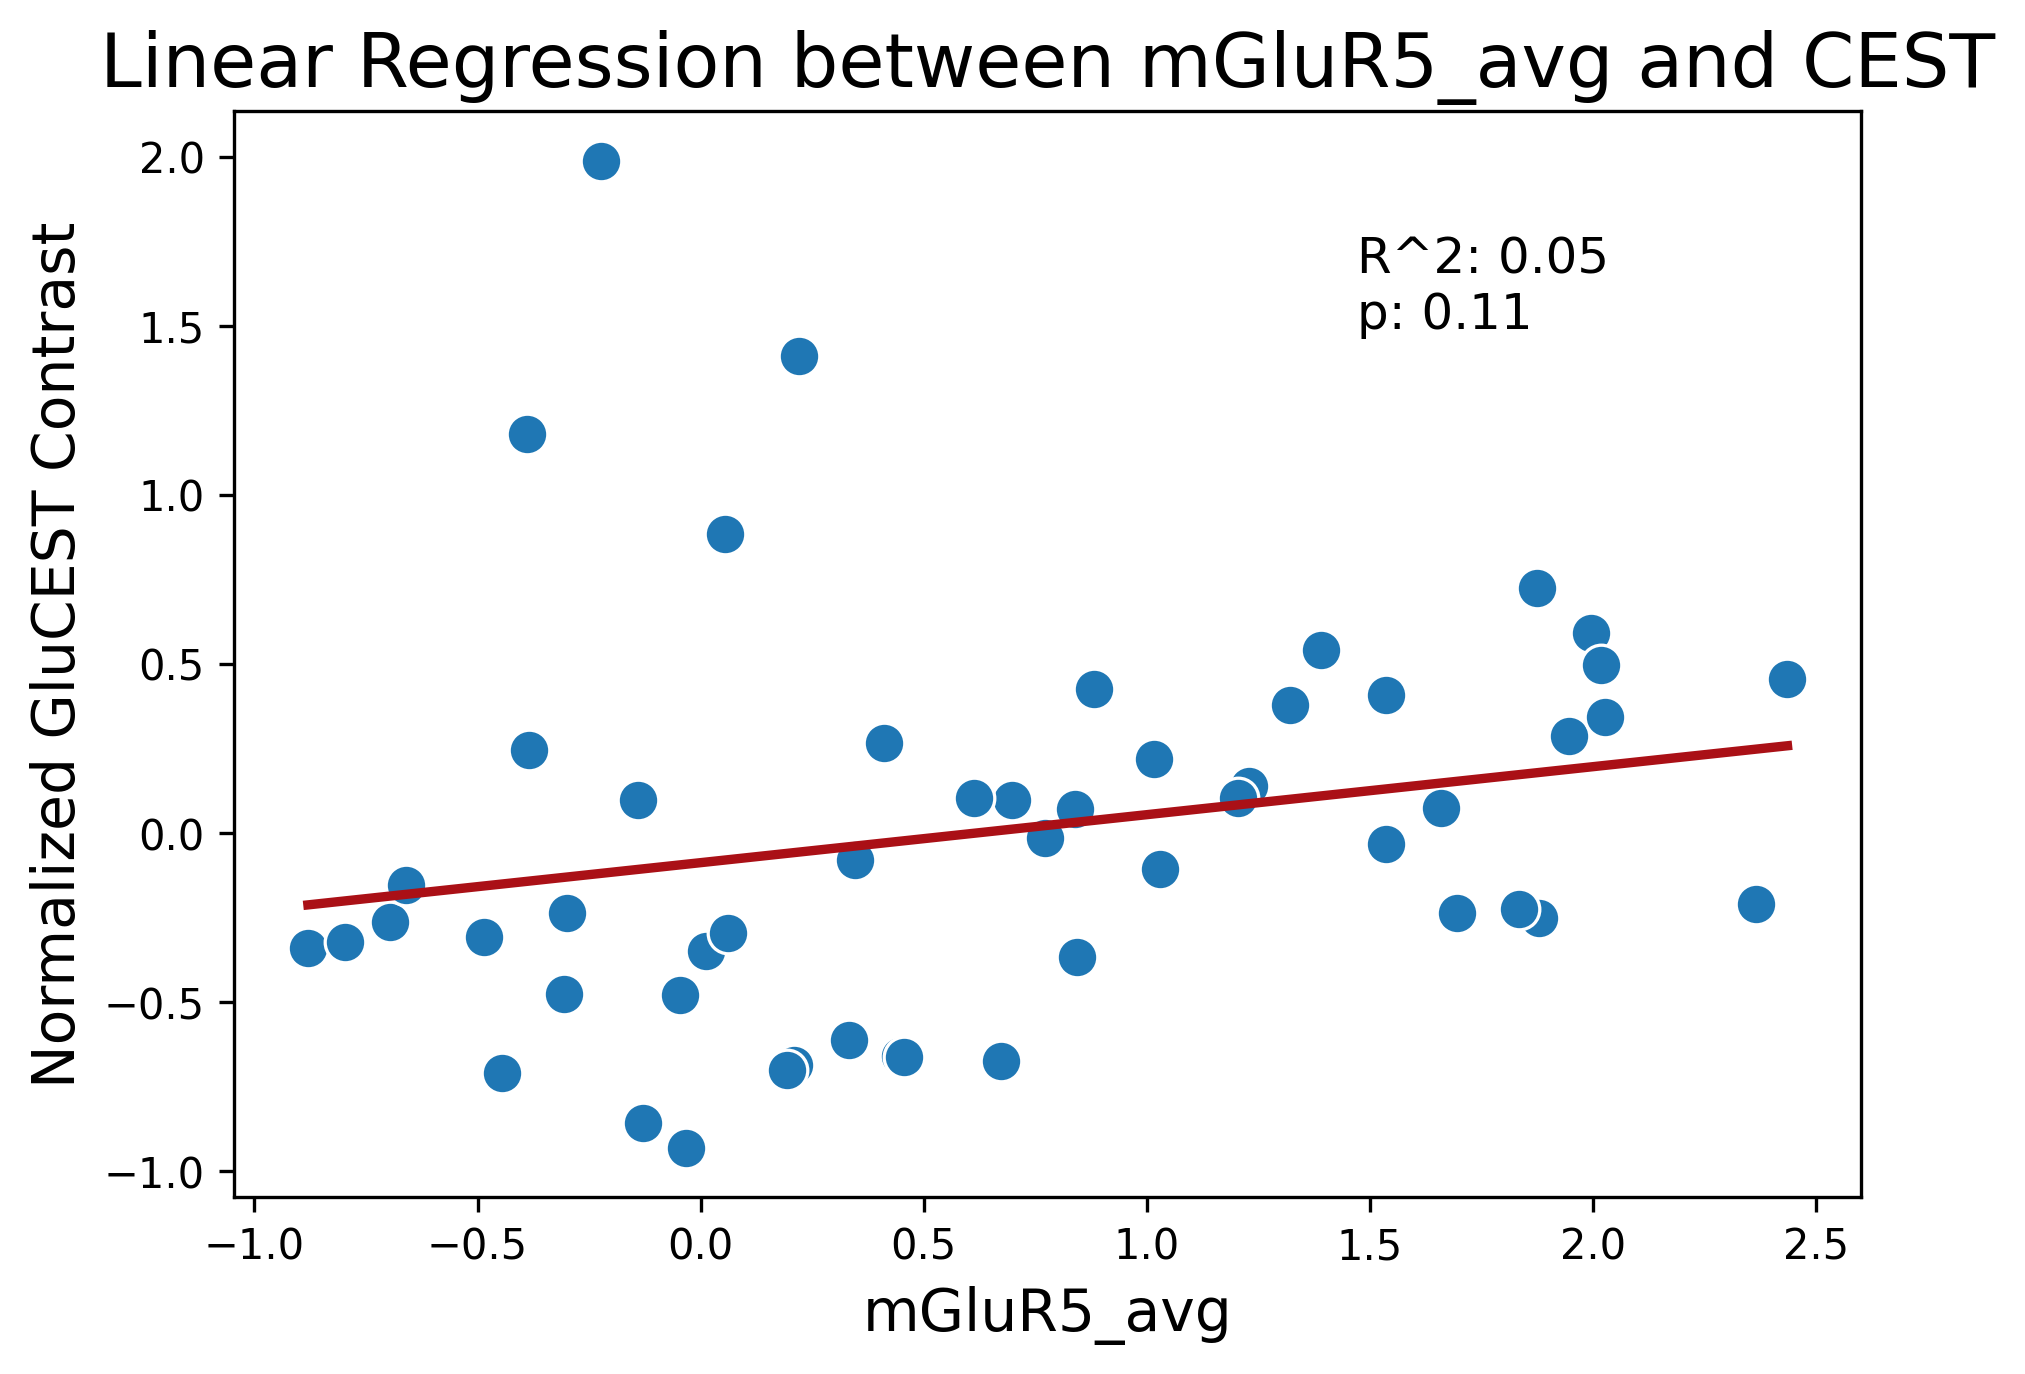

/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_89803/54851465.py:32: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=nmap, y='CEST_avg', data=graph_df, #color="dimgray", #hue='hstatus',


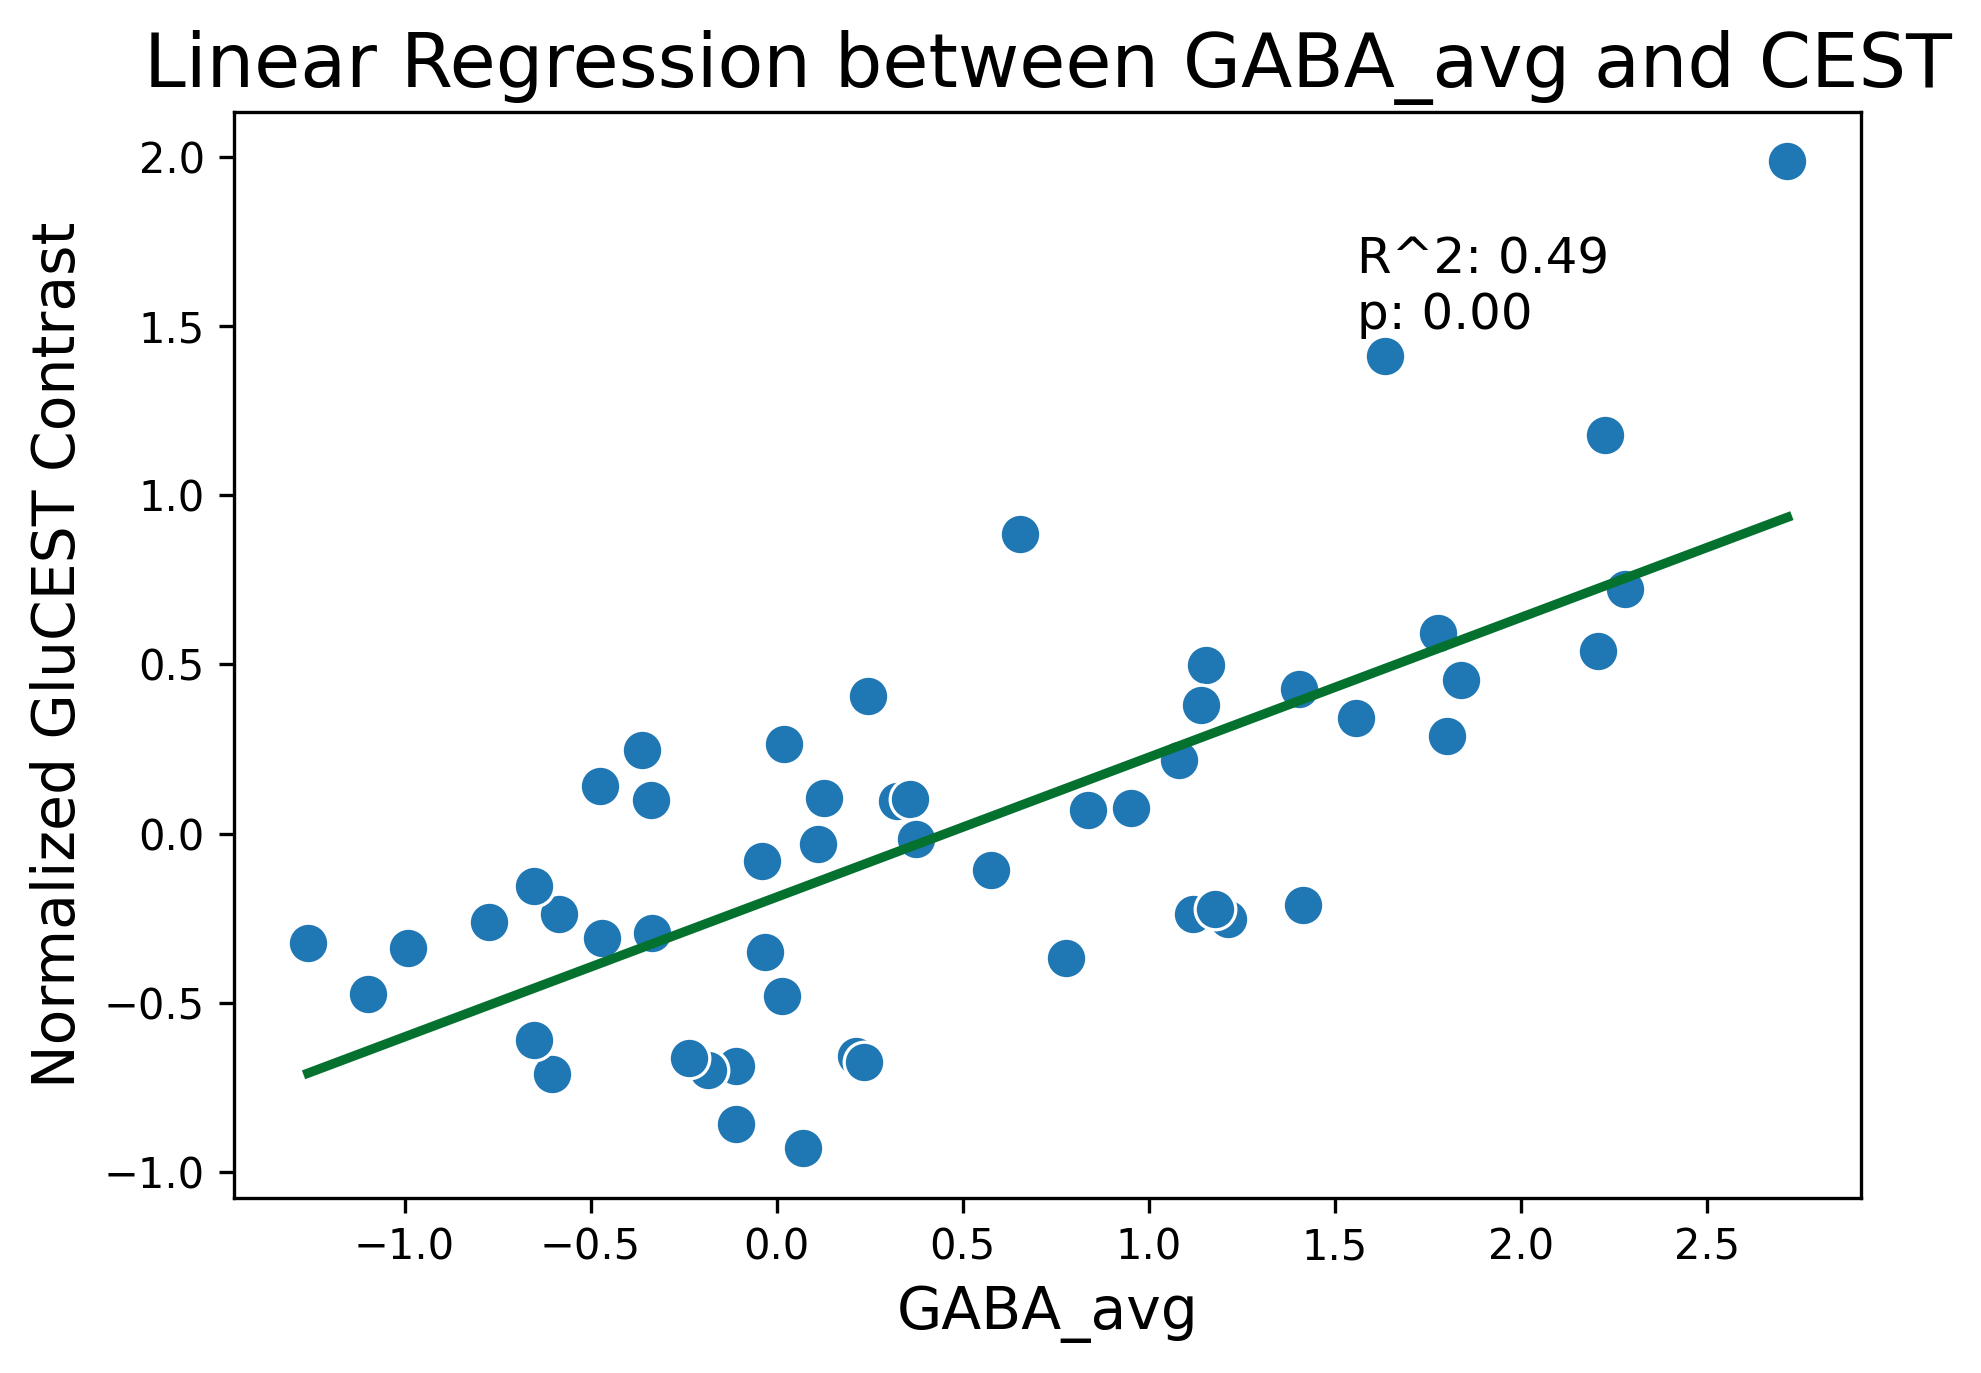

/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_89803/54851465.py:32: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=nmap, y='CEST_avg', data=graph_df, #color="dimgray", #hue='hstatus',


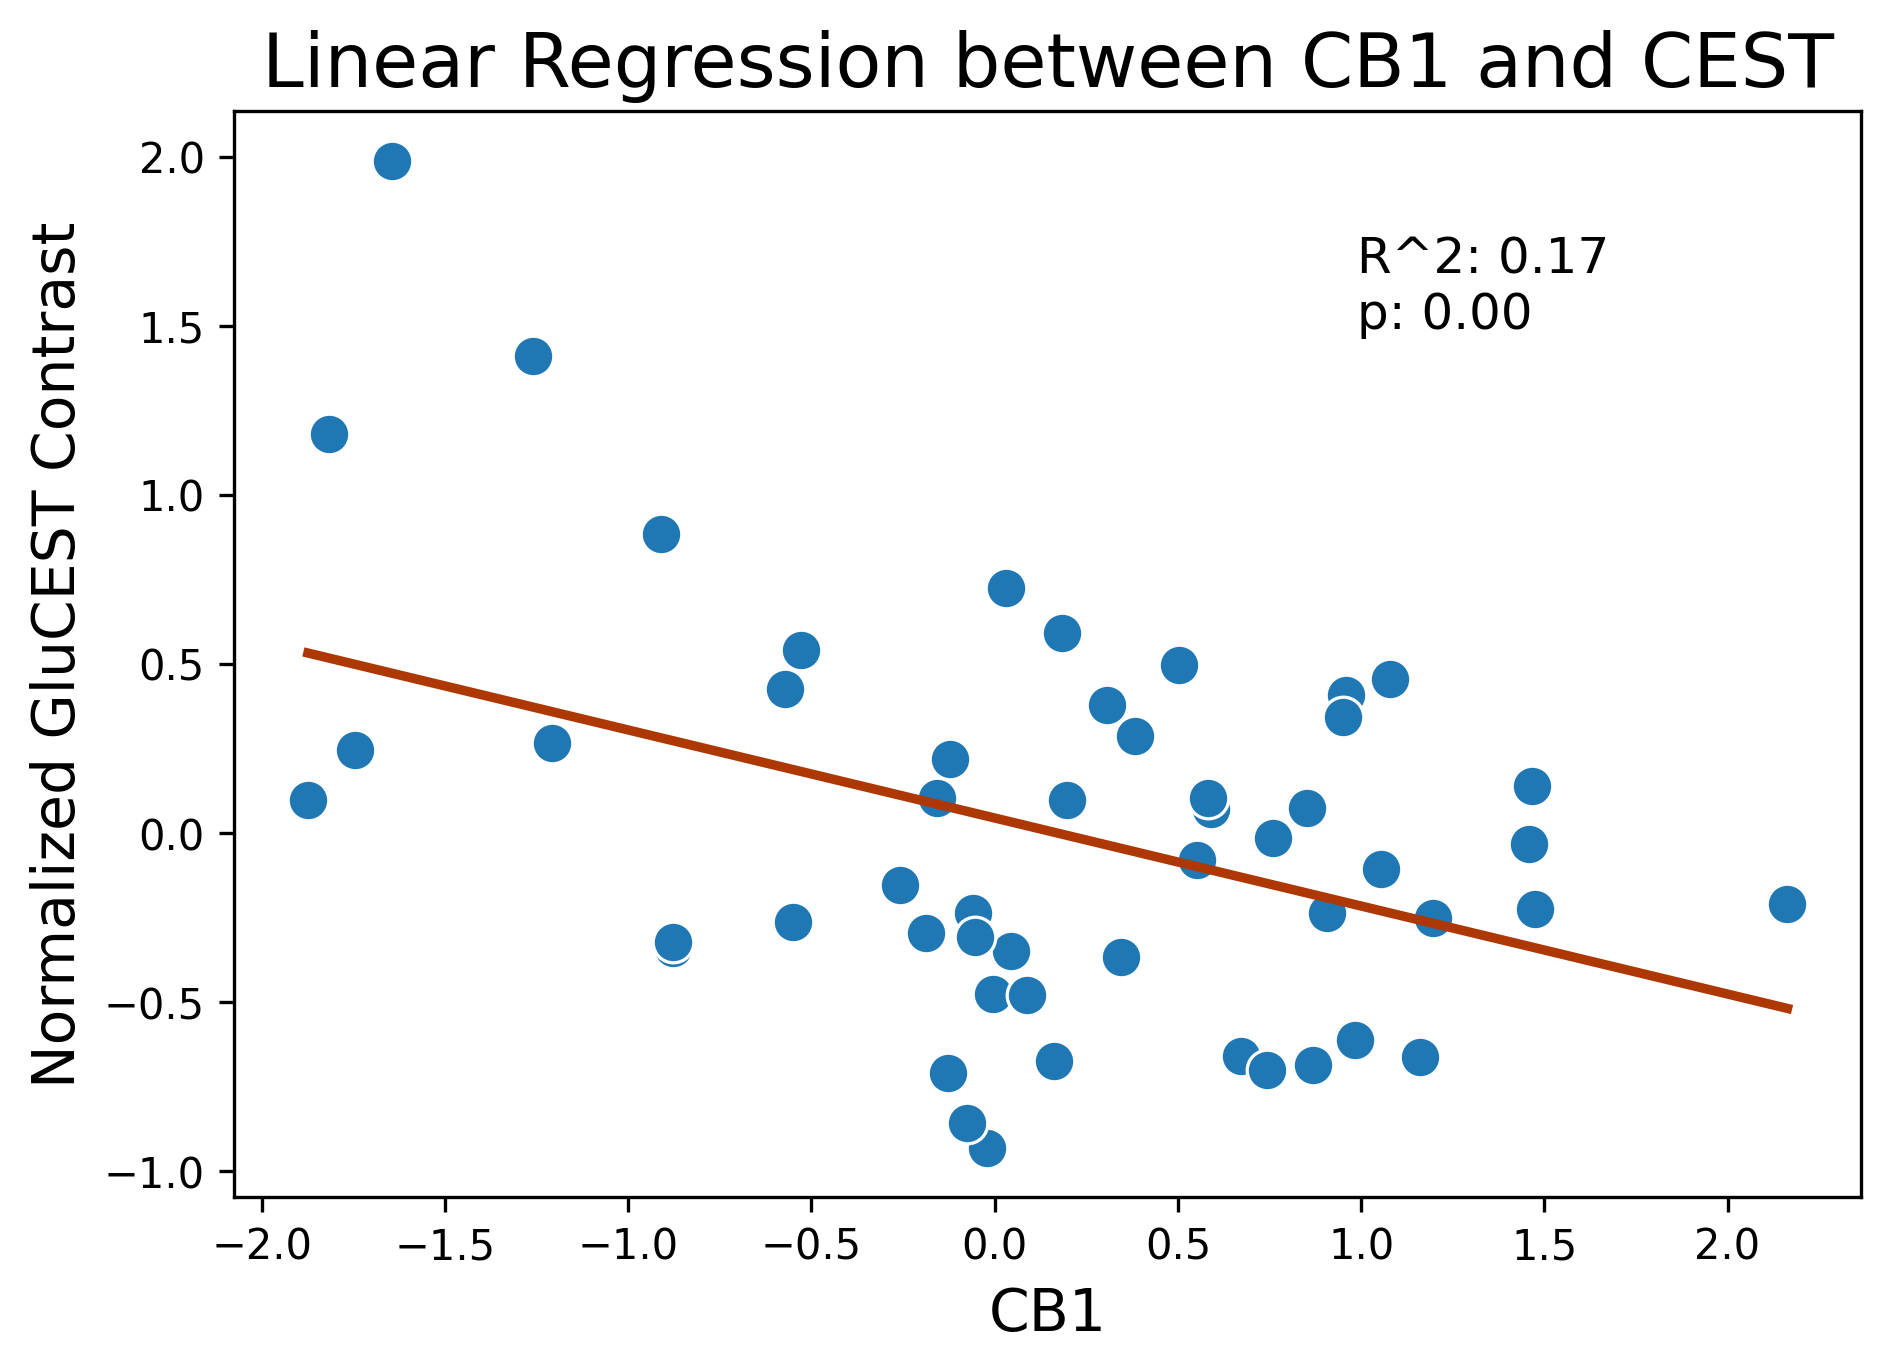

In [19]:
print(means_df)
nmap_palette = {
    "NMDA_avg": "Purples",   # Replace with actual nmap names and desired palettes
    "mGluR5_avg": "Reds",
    "GABA_avg": "Greens",
    "CB1": "Oranges"
    # Add more mappings as needed
}

lobe_shapes = {
    "frontal": "o",   # Replace with actual nmap names and desired palettes
    "parietal": "s",
    "occipital": "D"
    # Add more mappings as needed
}


for nmap in nmaps:
    #means_df[nmap] = pd.to_numeric(means_df[nmap], errors='coerce')
    #means_df['CEST_avg'] = pd.to_numeric(means_df['CEST_avg'], errors='coerce')
    graph_df = means_df[means_df['hstatus']=="HC"]  #.dropna(subset=[nmap, 'CEST_avg'])
    palette = nmap_palette.get(nmap) # Default to "Set1" if nmap not in dictionary
    scatter_colors = graph_df[nmap].apply(lambda x: palette[int((x - graph_df[nmap].min()) / (graph_df[nmap].max() - graph_df[nmap].min()) * (len(palette) - 1))])

    # Set up colors for trendline
    colors = sns.color_palette(palette)
    color = colors[5]
    
    #unique_shapes = graph_df['Lobe'].unique()
    #markers_list = [lobe_shapes[shape] for shape in unique_shapes]
    plt.figure(figsize=(7, 4.7), dpi=300)
    #plot = sns.lmplot(x=nmap, y='CEST_avg', hue='hstatus', data=graph_df, palette=palette)
    sns.scatterplot(x=nmap, y='CEST_avg', data=graph_df, #color="dimgray", #hue='hstatus', 
                    palette=colors, s=95) #palette
    sns.regplot(x=nmap, y='CEST_avg', data=graph_df, scatter=False, color=color, ci=None) # color

    plt.xlabel(nmap, fontsize=14)
    plt.ylabel("Normalized GluCEST Contrast", fontsize=14)
    plt.title('Linear Regression between ' + nmap + ' and CEST', fontsize=18)
    #plt.legend(title='Group', title_fontsize=12, fontsize=12) 
    
    #slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'PSY', 'CEST_avg'], graph_df.loc[graph_df['hstatus'] == 'PSY', nmap])
    #plt.text(0.47, 0.8, f'PSY Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=12)
    #slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'HC', 'CEST_avg'], graph_df.loc[graph_df['hstatus'] == 'HC', nmap])
    #plt.text(0.58, 0.8, f'HC Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=12)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df['CEST_avg'], graph_df[nmap])
    plt.text(0.69, 0.8, f'R^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=12)
    plt.show() 


In [45]:
outpath_box = '/Users/pecsok/Library/CloudStorage/Box-Box/GluCEST PhD/Manuscripts/Neuromaps/Results'
%matplotlib inline

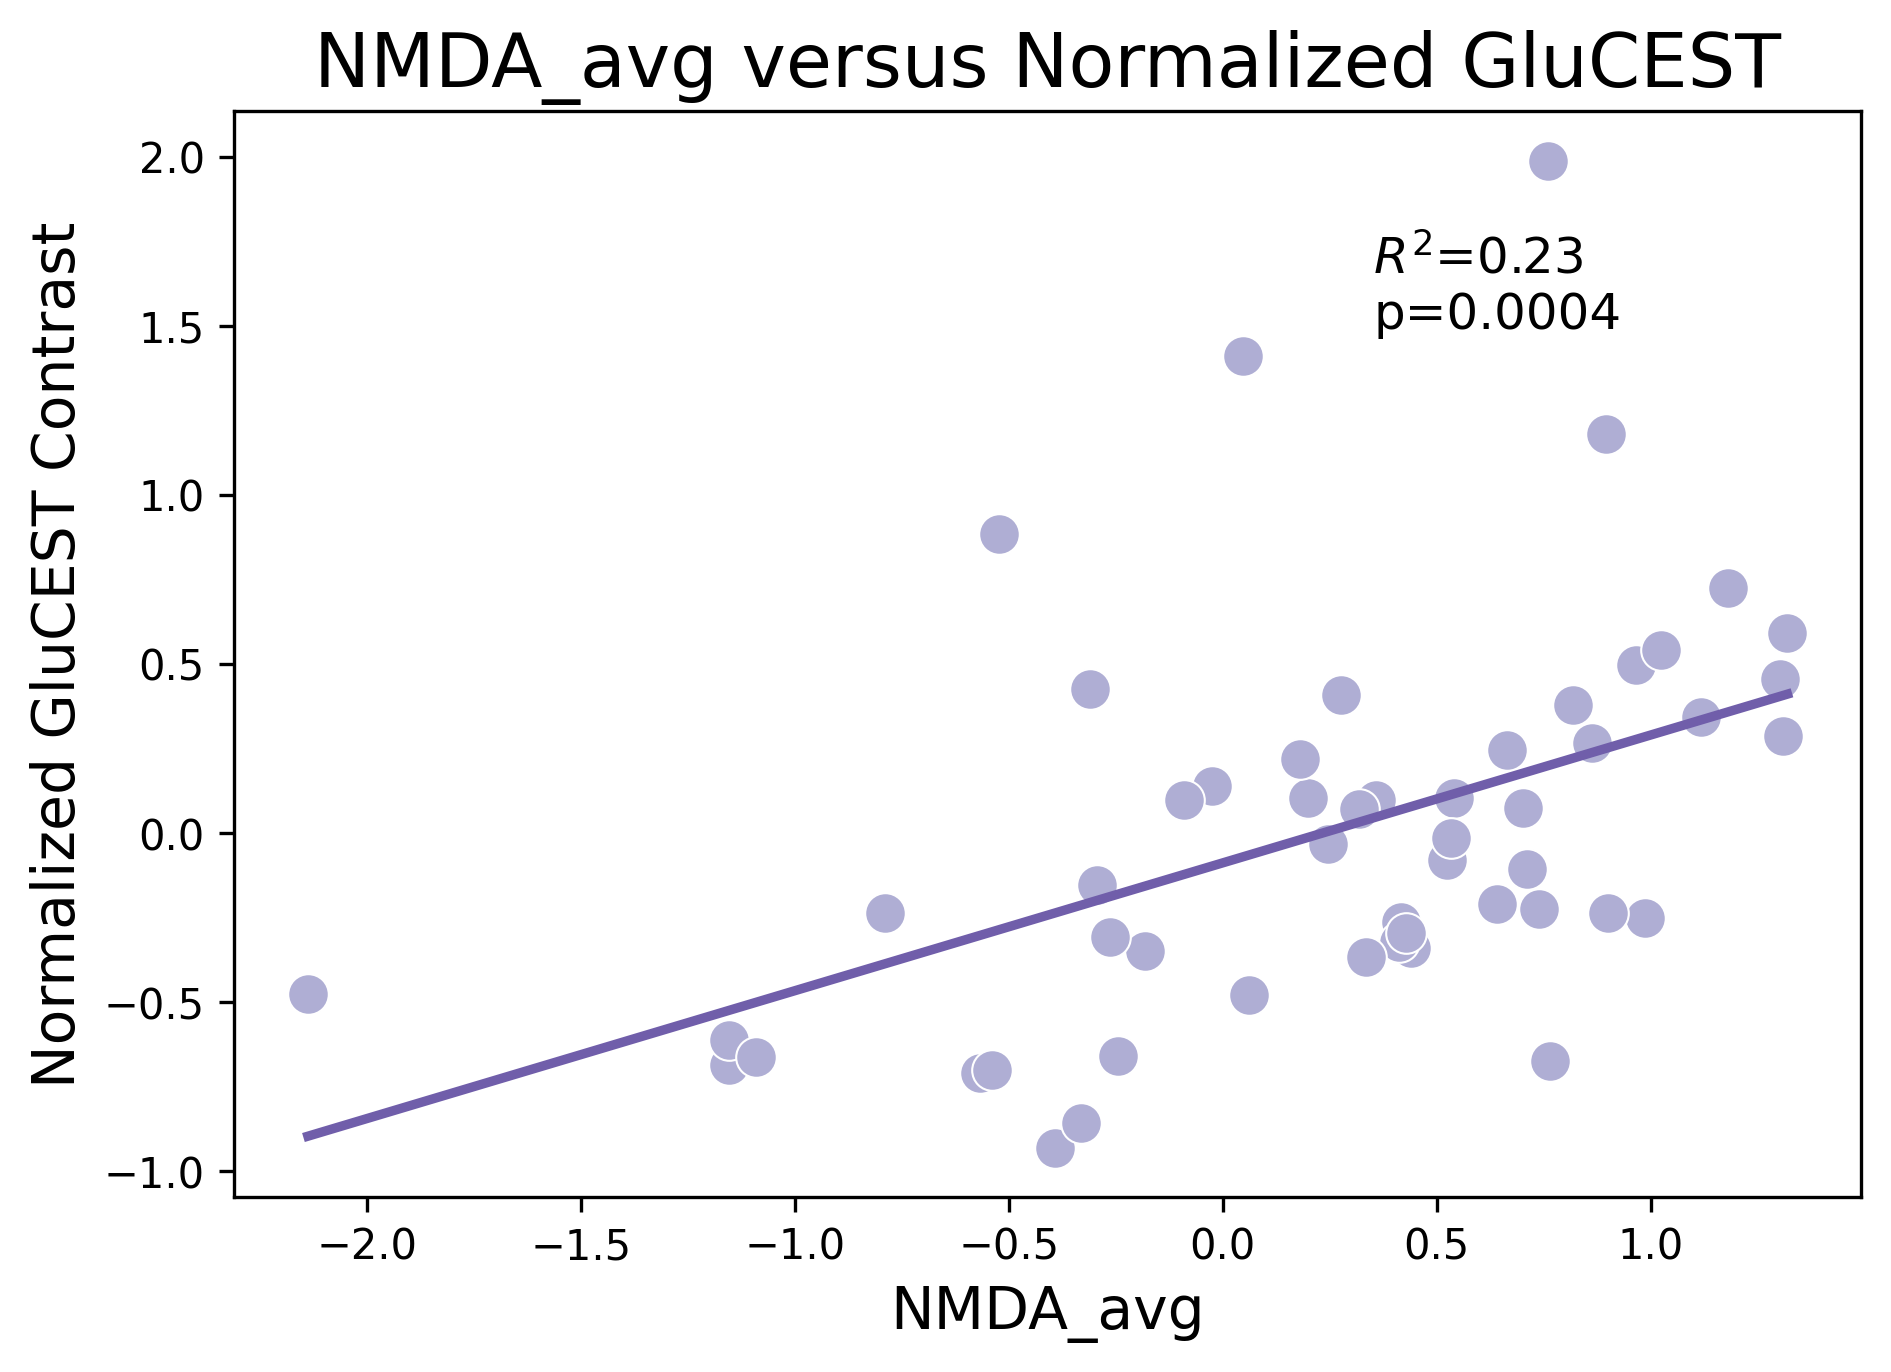

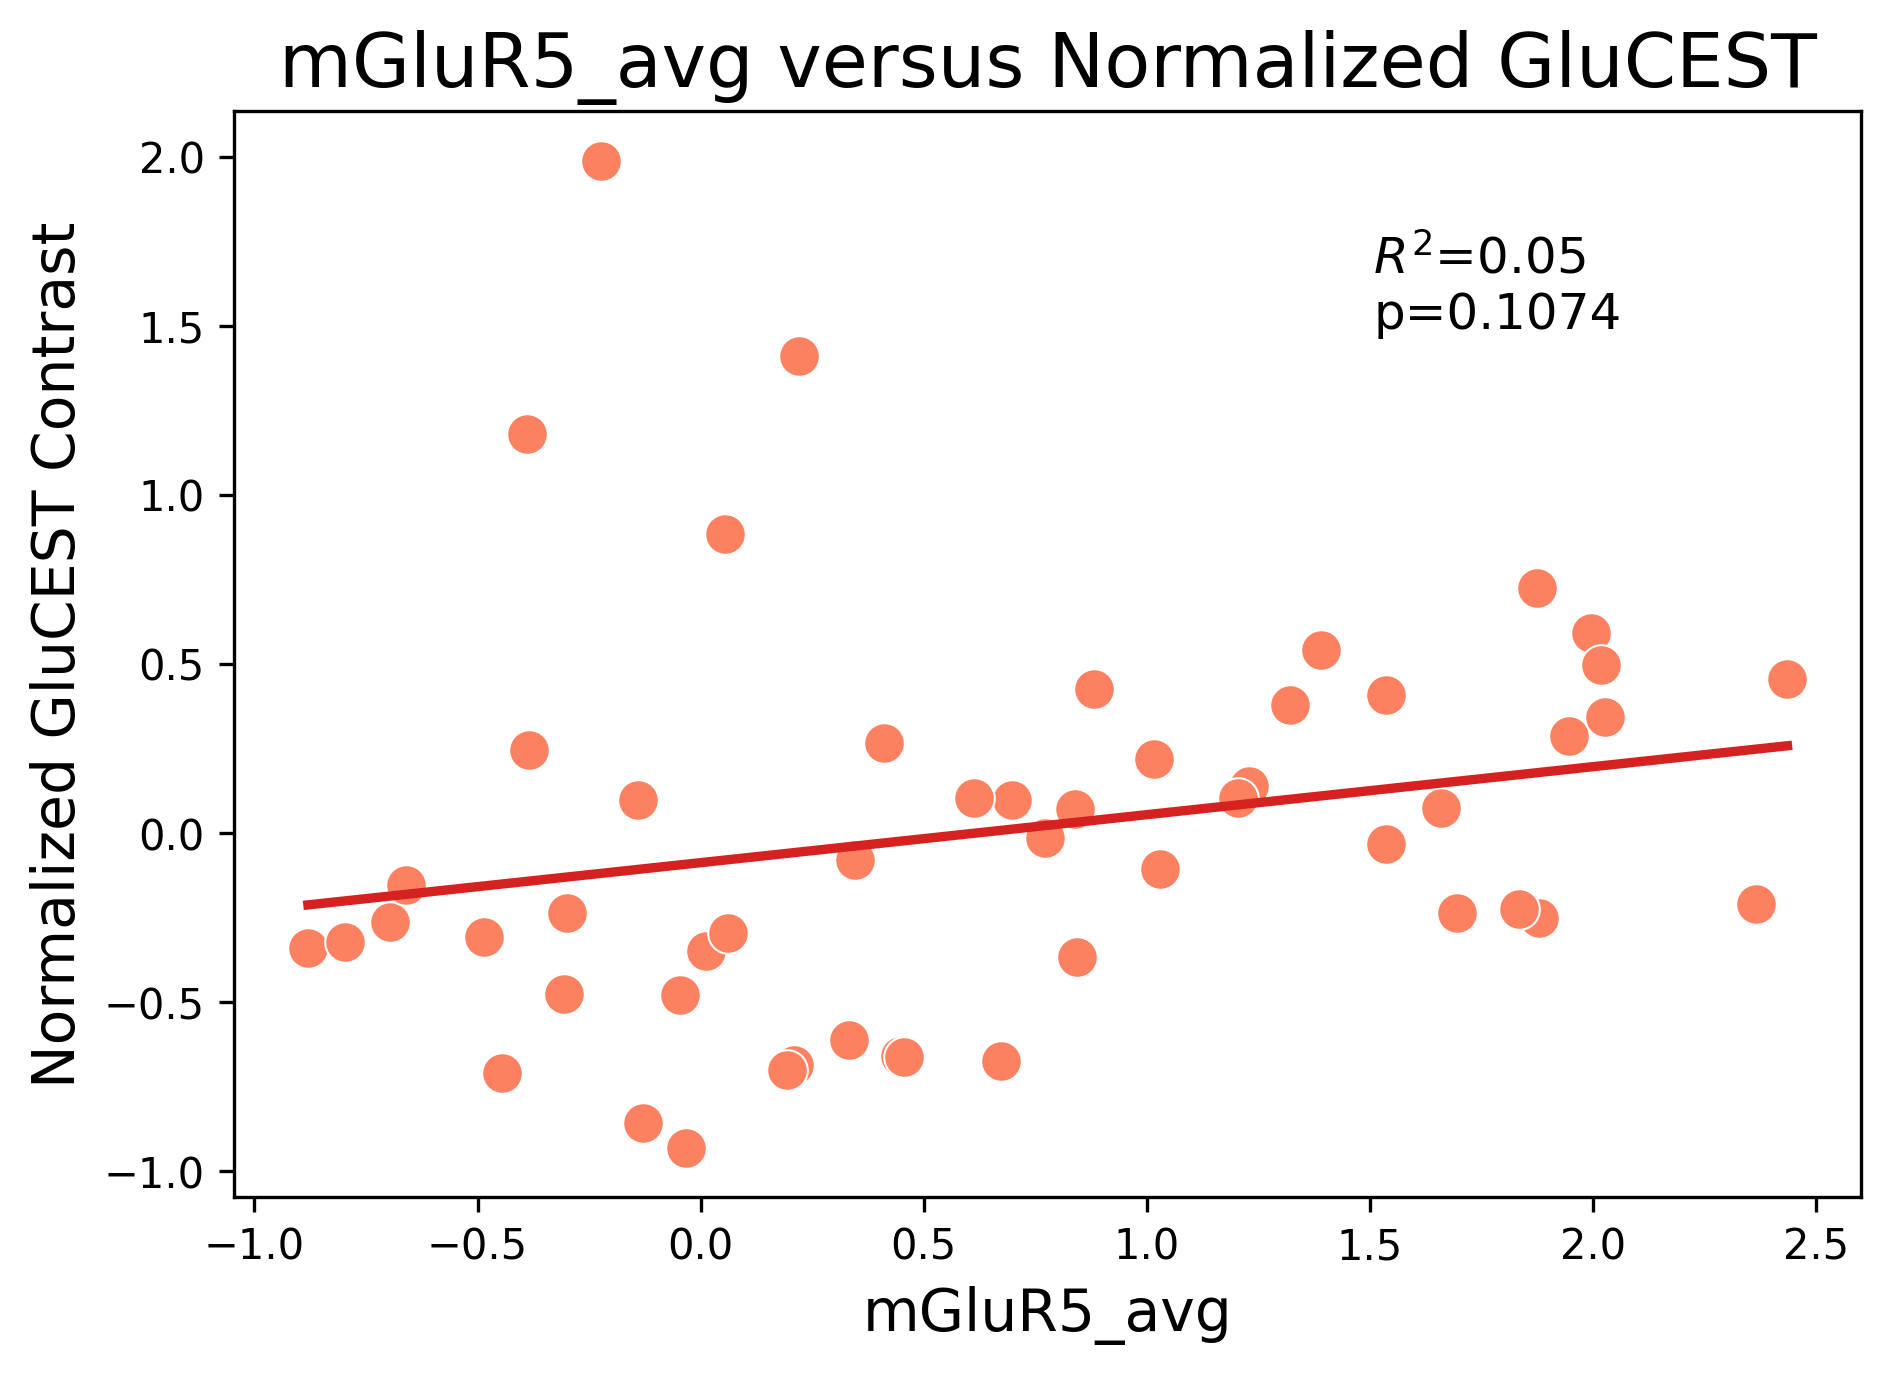

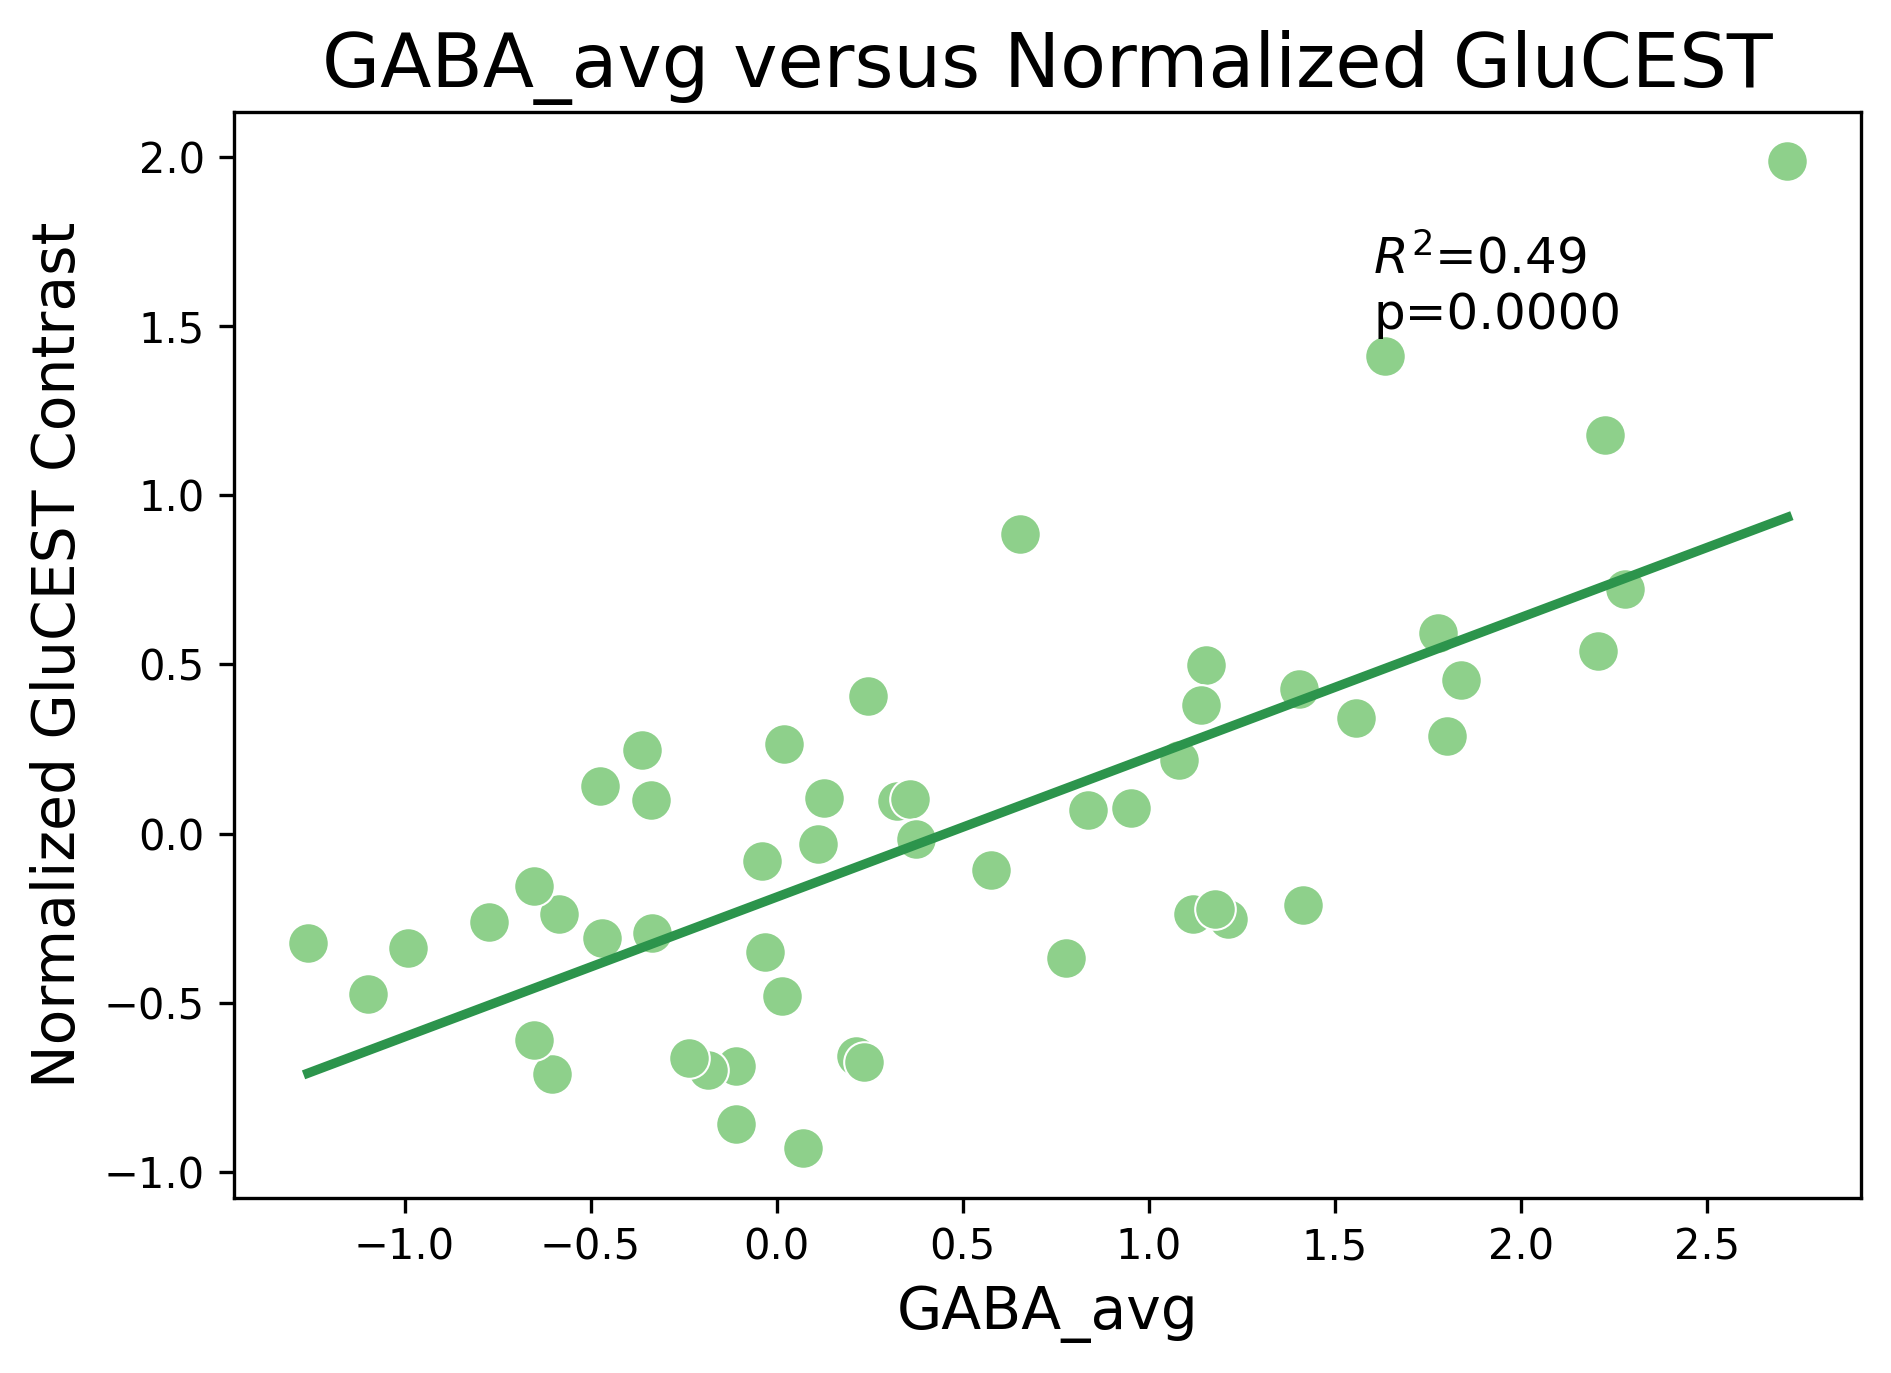

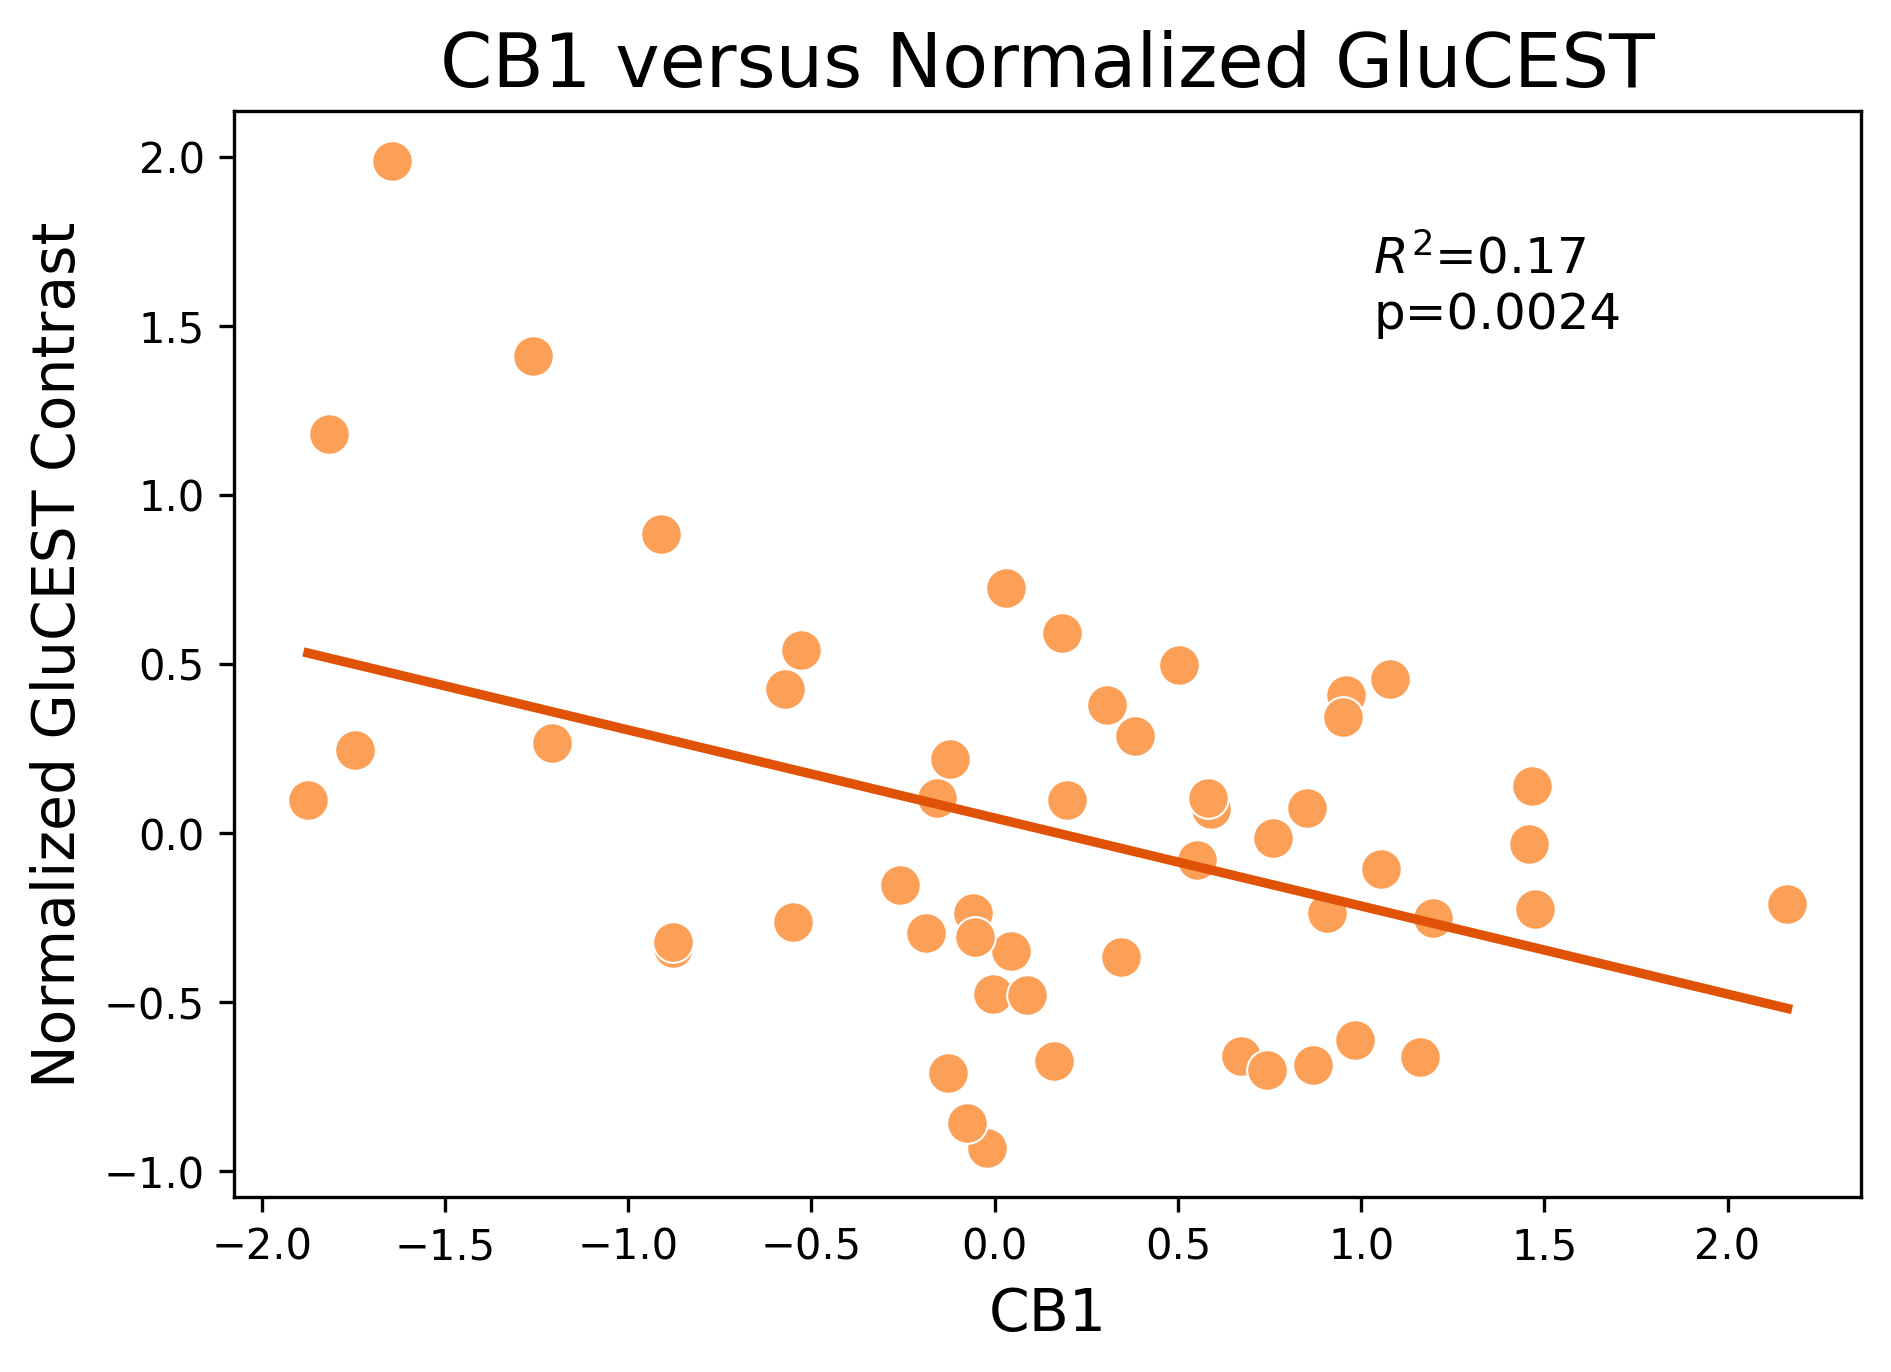

In [47]:
for nmap in nmaps:
    graph_df = means_df[means_df['hstatus'] == "HC"]  # Filter data for healthy controls
    palette = sns.color_palette(nmap_palette.get(nmap, "viridis"))  # Get the color palette for the nmap
    color = palette[2]  # Select a specific color from the palette (e.g., the third color)
    linecolor = palette[4]
    
    plt.figure(figsize=(7, 4.7), dpi=300)
    
    # Scatter plot with a uniform color
    sns.scatterplot(x=nmap, y='CEST_avg', data=graph_df, color=color, s=95, edgecolor='w', linewidth=0.5)
    
    # Regression line
    sns.regplot(x=nmap, y='CEST_avg', data=graph_df, scatter=False, color=linecolor, ci=None)
    
    # Set plot labels and title
    plt.xlabel(nmap, fontsize=14)
    plt.ylabel("Normalized GluCEST Contrast", fontsize=14)
    plt.title(f'{nmap} versus Normalized GluCEST', fontsize=18)
    
    # Add R^2 and p-value
    slope, intercept, r_value, p_value, std_err = linregress(graph_df['CEST_avg'], graph_df[nmap])
    plt.text(0.7, 0.8, f'$R^2$={r_value**2:.2f}\np={p_value:.4f}', transform=plt.gca().transAxes, fontsize=12)
   
    # Save the plot as a vector image
    output_file = os.path.join(outpath_box, f"{nmap}_CEST_plot.eps")
    plt.savefig(output_file, format='eps', dpi=300, bbox_inches='tight')
    plt.show()
    
    

### Run Regressions by cortical lobe

                         Parcel hstatus  CEST_avg  NMDA_avg  mGluR5_avg  \
0    caudalanteriorcingulate_5R      HC  0.140048 -0.026330    1.229935   
1    caudalanteriorcingulate_5R     PSY -0.011085 -0.026330    1.229935   
2                     cuneus_3R      HC  0.884299 -0.522157    0.053661   
3                     cuneus_3R     PSY  0.305783 -0.522157    0.053661   
4                     cuneus_5R      HC  1.411665  0.046650    0.220775   
..                          ...     ...       ...       ...         ...   
99           superiorfrontal_7R     PSY -0.455633  0.739121    1.834678   
100          superiorfrontal_8R      HC -0.857712 -0.331275   -0.129873   
101          superiorfrontal_8R     PSY -0.800876 -0.331275   -0.129873   
102          superiorfrontal_9R      HC -0.154002 -0.293822   -0.660154   
103          superiorfrontal_9R     PSY -0.372532 -0.293822   -0.660154   

     GABA_avg       Lobe  
0   -0.473436    frontal  
1   -0.473436    frontal  
2    0.654213  occ

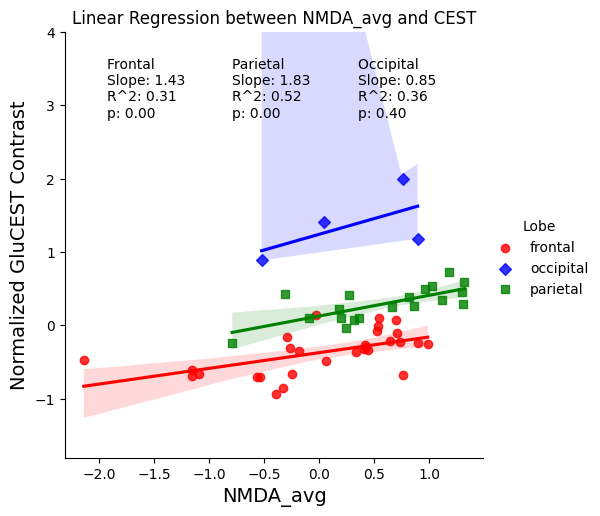

mGluR5_avg


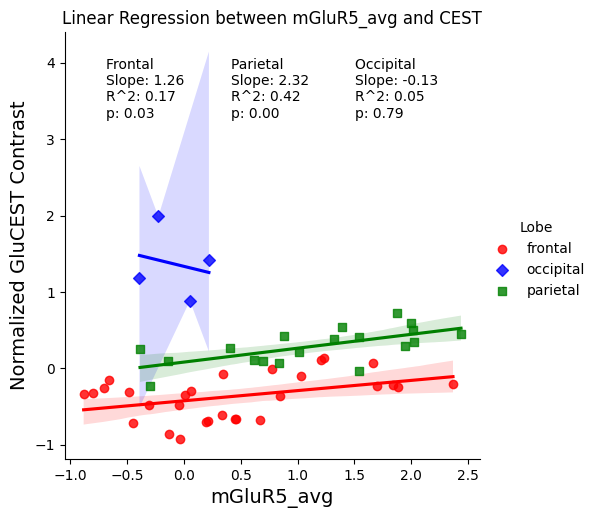

GABA_avg


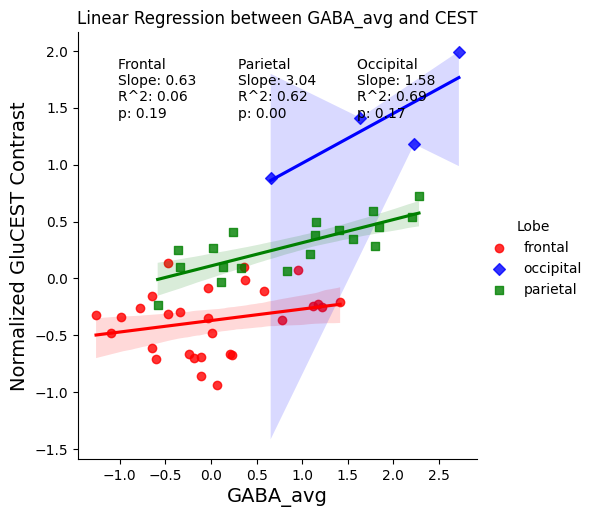

In [33]:
print(means_df)
nmap_palette = {
    "NMDA_avg": "Purples",   # Replace with actual nmap names and desired palettes
    "mGluR5_avg": "Reds",
    "GABA_avg": "Greens",
    "D2": "Oranges"
    # Add more mappings as needed
}

lobe_shapes = {
    "frontal": "o",   # Replace with actual nmap names and desired palettes
    "parietal": "s",
    "occipital": "D"
    # Add more mappings as needed
}

lobe_palette = {
    'frontal': 'red',  # Blue
    'parietal': 'green',  # Orange
    'occipital': 'blue'  # Green
}

for nmap in nmaps:
    print(nmap)
    #means_df[nmap] = pd.to_numeric(means_df[nmap], errors='coerce')
    #means_df['CEST_avg'] = pd.to_numeric(means_df['CEST_avg'], errors='coerce')
    graph_df = means_df[means_df['hstatus']=='HC']  #.dropna(subset=[nmap, 'CEST_avg'])
    palette = nmap_palette.get(nmap) # Default to "Set1" if nmap not in dictionary

    unique_shapes = graph_df['Lobe'].unique()
    markers_list = [lobe_shapes[shape] for shape in unique_shapes]

    plot = sns.lmplot(x=nmap, y='CEST_avg', hue='Lobe', data=graph_df, markers=markers_list, palette=lobe_palette)
    
    if nmap == 'NMDA_avg':
        plot.set(ylim=(None, 4))
    plt.xlabel(nmap, fontsize=14)
    plt.ylabel("Normalized GluCEST Contrast",fontsize=14)
    plt.title('Linear Regression between ' + nmap + ' and CEST')
    
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['Lobe'] == 'frontal', 'CEST_avg'], graph_df.loc[graph_df['Lobe'] == 'frontal', nmap])
    plt.text(0.1, 0.8, f'Frontal \nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['Lobe'] == 'parietal', 'CEST_avg'], graph_df.loc[graph_df['Lobe'] == 'parietal', nmap])
    plt.text(0.4, 0.8, f'Parietal \nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['Lobe'] == 'occipital', 'CEST_avg'], graph_df.loc[graph_df['Lobe'] == 'occipital', nmap])
    plt.text(0.7, 0.8, f'Occipital \nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)

    plt.show() 

In [7]:
means_df

,Parcel,hstatus,CEST_avg,NMDA_avg,mGluR5_avg,GABA_avg,Lobe
0,caudalanteriorcingulate_5R,HC,0.140048,-0.026330,1.229935,-0.473436,frontal
1,caudalanteriorcingulate_5R,PSY,-0.011085,-0.026330,1.229935,-0.473436,frontal
2,cuneus_3R,HC,0.884299,-0.522157,0.053661,0.654213,occipital
3,cuneus_3R,PSY,0.305783,-0.522157,0.053661,0.654213,occipital
4,cuneus_5R,HC,1.411665,0.046650,0.220775,1.635019,occipital
...,...,...,...,...,...,...,...
99,superiorfrontal_7R,PSY,-0.455633,0.739121,1.834678,1.177836,frontal
100,superiorfrontal_8R,HC,-0.857712,-0.331275,-0.129873,-0.108921,frontal
101,superiorfrontal_8R,PSY,-0.800876,-0.331275,-0.129873,-0.108921,frontal
102,superiorfrontal_9R,HC,-0.154002,-0.293822,-0.660154,-0.651477,frontal


,Parcel,Lobe,hstatus,nmap,nmap_value
0,caudalanteriorcingulate_5R,frontal,HC,NMDA_avg,-0.026330
1,caudalanteriorcingulate_5R,frontal,PSY,NMDA_avg,-0.026330
2,cuneus_3R,occipital,HC,NMDA_avg,-0.522157
3,cuneus_3R,occipital,PSY,NMDA_avg,-0.522157
4,cuneus_5R,occipital,HC,NMDA_avg,0.046650
...,...,...,...,...,...
307,superiorfrontal_7R,frontal,PSY,mGluR5_avg,1.834678
308,superiorfrontal_8R,frontal,HC,mGluR5_avg,-0.129873
309,superiorfrontal_8R,frontal,PSY,mGluR5_avg,-0.129873
310,superiorfrontal_9R,frontal,HC,mGluR5_avg,-0.660154


frontal


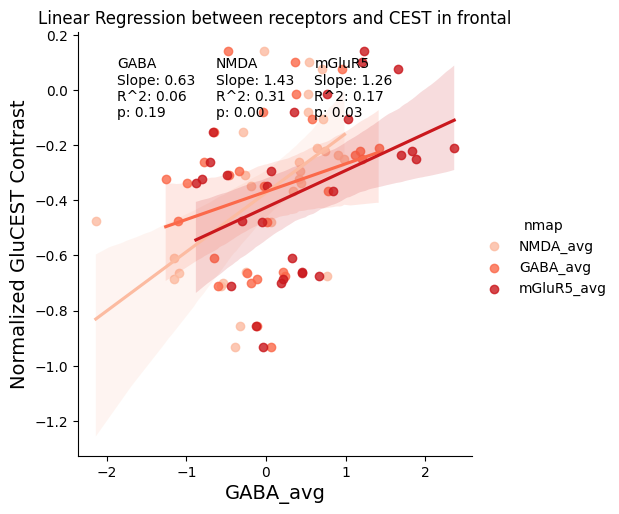

parietal


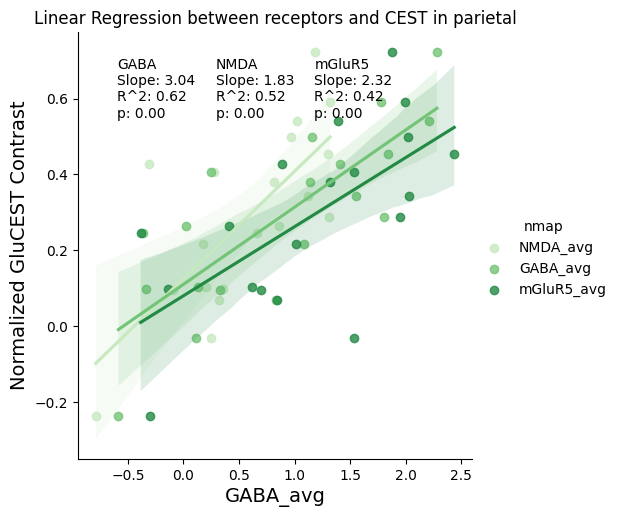

occipital


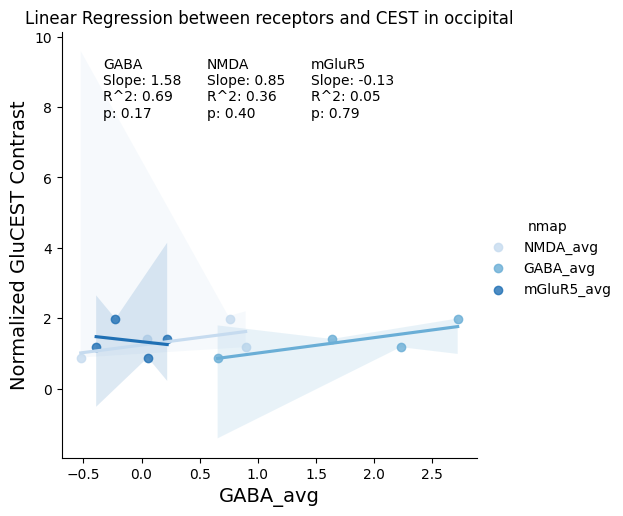

In [20]:
lobe_palette = {
    "frontal": "Reds",   # Replace with actual nmap names and desired palettes
    "parietal": "Greens",
    "occipital": "Blues"
    # Add more mappings as needed
}

# Make new bespoke long_df
means_long_df = means_df.melt(
    id_vars=['Parcel', 'Lobe', 'hstatus','CEST_avg'], 
    value_vars=['NMDA_avg', 'GABA_avg', 'mGluR5_avg'], 
    var_name='nmap', 
    value_name='nmap_value'
)
means_long_df

for lobe in lobes:
    print(lobe)
    
    graph_df = means_long_df[means_long_df['Lobe']==lobe]  #.dropna(subset=[nmap, 'CEST_avg'])
    graph_df = graph_df[graph_df['hstatus']=='HC']
    palette = lobe_palette.get(lobe) # Default to "Set1" if nmap not in dictionary

    #unique_shapes = graph_df['Lobe'].unique()
    #markers_list = [lobe_shapes[shape] for shape in unique_shapes]

    plot = sns.lmplot(x='nmap_value', y='CEST_avg', hue='nmap', data=graph_df, palette=palette) #, markers=markers_list, 
    
    plt.xlabel(nmap, fontsize=14)
    plt.ylabel("Normalized GluCEST Contrast",fontsize=14)
    plt.title('Linear Regression between receptors and CEST in ' + lobe)
    
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['nmap'] == 'GABA_avg', 'CEST_avg'], graph_df.loc[graph_df['nmap'] == 'GABA_avg', 'nmap_value'])
    plt.text(0.1, 0.8, f'GABA\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=10)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['nmap'] == 'NMDA_avg', 'CEST_avg'], graph_df.loc[graph_df['nmap'] == 'NMDA_avg', 'nmap_value'])
    plt.text(0.35, 0.8, f'NMDA\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=10)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['nmap'] == 'mGluR5_avg', 'CEST_avg'], graph_df.loc[graph_df['nmap'] == 'mGluR5_avg', 'nmap_value'])
    plt.text(0.6, 0.8, f'mGluR5\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=10)

    plt.show() 

frontal
NMDA_avg


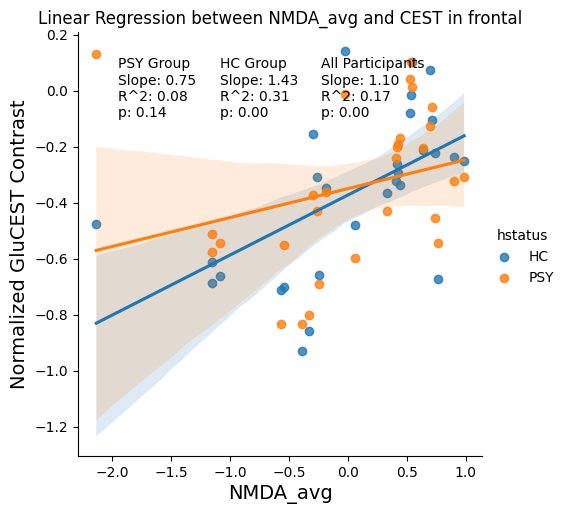

mGluR5_avg


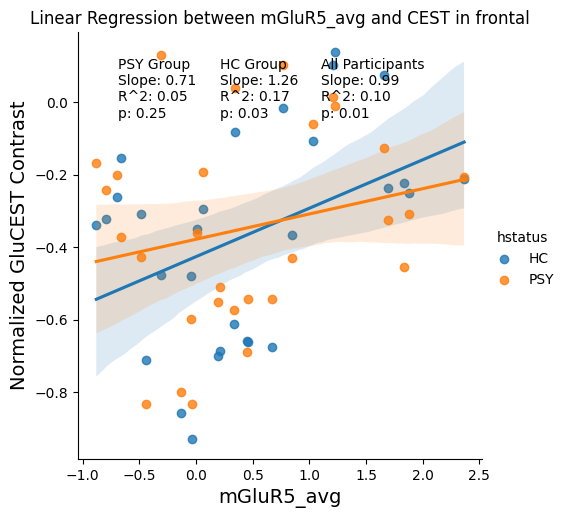

GABA_avg


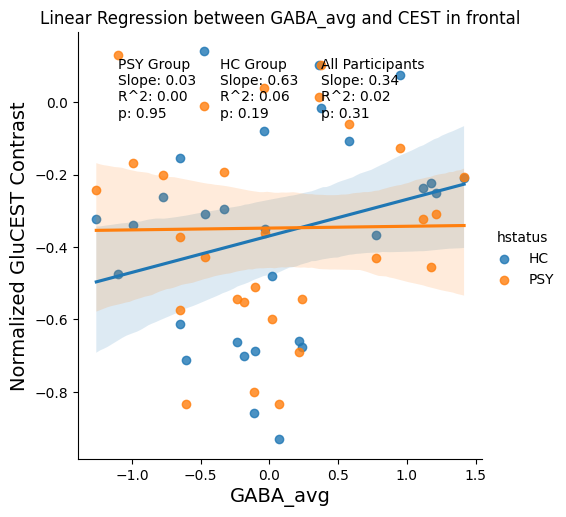

parietal
NMDA_avg


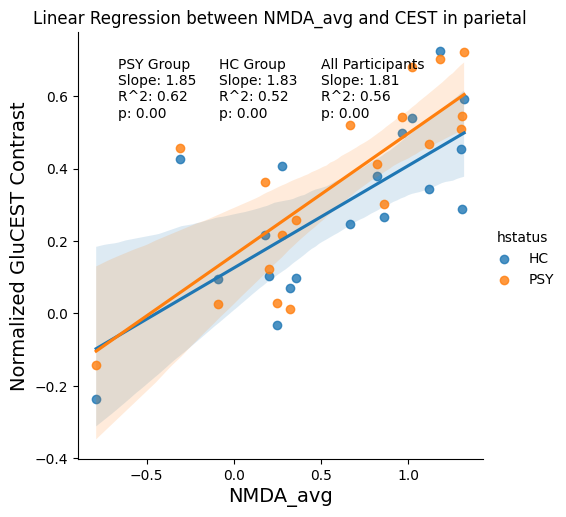

mGluR5_avg


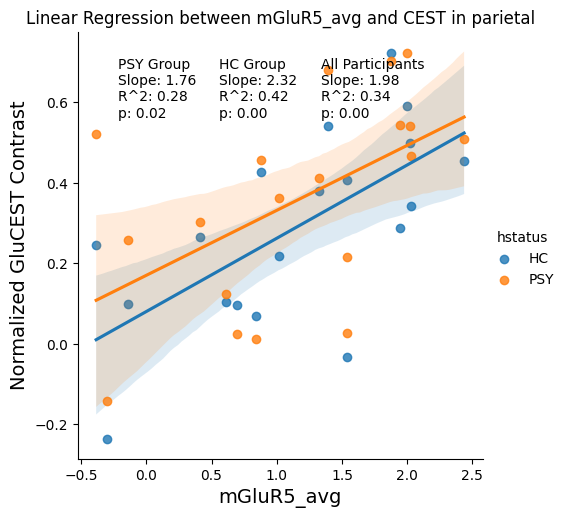

GABA_avg


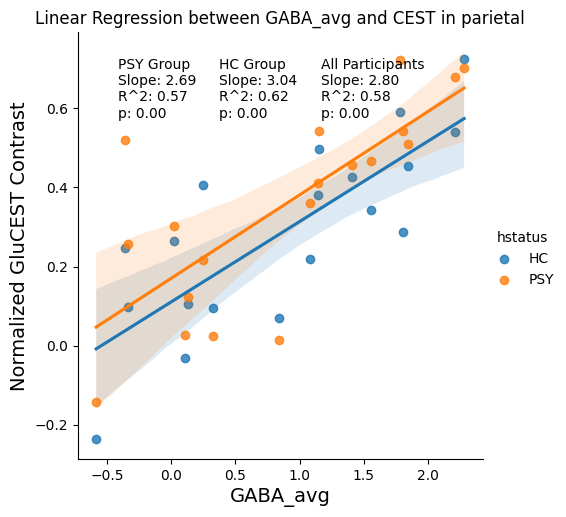

occipital
NMDA_avg


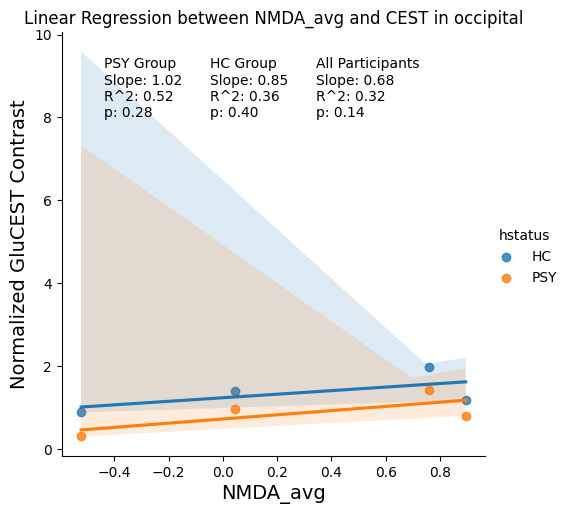

mGluR5_avg


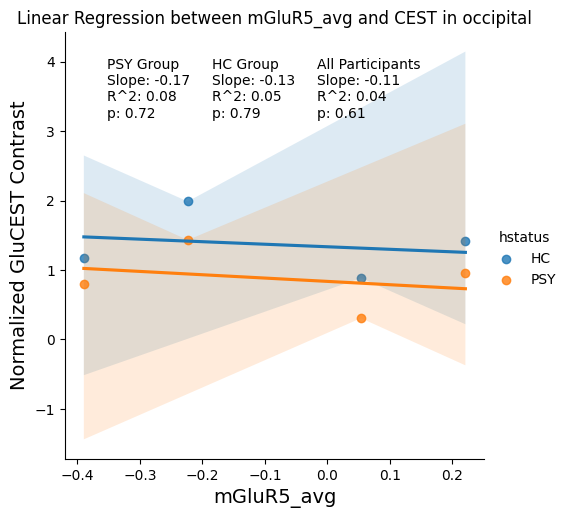

GABA_avg


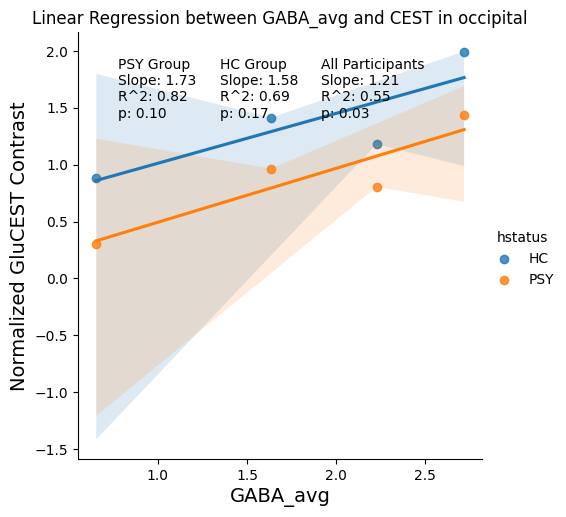

In [19]:
for lobe in lobes:
    print(lobe)
    for nmap in nmaps:
        print(nmap)
        graph_df = means_df[means_df['Lobe']==lobe]  #.dropna(subset=[nmap, 'CEST_avg'])
        palette = nmap_palette.get(nmap) # Default to "Set1" if nmap not in dictionary
    
        #unique_shapes = graph_df['Lobe'].unique()
        #markers_list = [lobe_shapes[shape] for shape in unique_shapes]
    
        plot = sns.lmplot(x=nmap, y='CEST_avg', hue='hstatus', data=graph_df) #, markers=markers_list, palette=palette
        
        plt.xlabel(nmap, fontsize=14)
        plt.ylabel("Normalized GluCEST Contrast",fontsize=14)
        plt.title('Linear Regression between ' + nmap + ' and CEST in ' + lobe)
        
        slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'PSY', 'CEST_avg'], graph_df.loc[graph_df['hstatus'] == 'PSY', nmap])
        plt.text(0.1, 0.8, f'PSY Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=10)
        slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'HC', 'CEST_avg'], graph_df.loc[graph_df['hstatus'] == 'HC', nmap])
        plt.text(0.35, 0.8, f'HC Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=10)
        slope, intercept, r_value, p_value, std_err = linregress(graph_df['CEST_avg'], graph_df[nmap])
        plt.text(0.6, 0.8, f'All Participants\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes, fontsize=10)
    
        plt.show() 

In [5]:
# Create interaction plots
from statsmodels.regression.mixed_linear_model import MixedLM

for nmap in nmaps:
    formula = 'CEST_avg ~ nmap * Lobe + (1 | subjid)'
    
    # Prepare the interaction model with random effect for subject
    model = MixedLM.from_formula('CEST_avg ~' + nmap + '* Lobe', data=means_df)
    
    # Fit the model
    result = model.fit()
    
    # Print summary of the model
    print(result.summary())

lobe_shapes = {
    "frontal": "o",   # Replace with actual nmap names and desired palettes
    "parietal": "s",
    "occipital": "D"
    # Add more mappings as needed
}

for nmap in nmaps:
    print(nmap)
    #means_df[nmap] = pd.to_numeric(means_df[nmap], errors='coerce')
    #means_df['CEST_avg'] = pd.to_numeric(means_df['CEST_avg'], errors='coerce')
    graph_df = means_df  #.dropna(subset=[nmap, 'CEST_avg'])
    palette = nmap_palette.get(nmap) # Default to "Set1" if nmap not in dictionary

    unique_shapes = graph_df['Lobe'].unique()
    markers_list = [lobe_shapes[shape] for shape in unique_shapes]

    plot = sns.lmplot(x=nmap, y='CEST_avg', hue='Lobe', data=graph_df, markers=markers_list, palette=palette)
    
    plt.xlabel(nmap, fontsize=14)
    plt.ylabel("Normalized GluCEST Contrast",fontsize=14)
    plt.title('Linear Regression between ' + nmap + ' and CEST')
    
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['Lobe'] == 'frontal', 'CEST_avg'], graph_df.loc[graph_df['Lobe'] == 'frontal', nmap])
    plt.text(0.1, 0.8, f'Frontal \nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['Lobe'] == 'parietal', 'CEST_avg'], graph_df.loc[graph_df['Lobe'] == 'parietal', nmap])
    plt.text(0.4, 0.8, f'Parietal \nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['Lobe'] == 'occipital', 'CEST_avg'], graph_df.loc[graph_df['Lobe'] == 'occipital', nmap])
    plt.text(0.7, 0.8, f'Occipital \nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)

    plt.show() 

NameError: name 'means_df' is not defined

NMDA_avg


/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_14437/4084737229.py:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_14437/4084737229.py:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_14437/4084737229.py:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


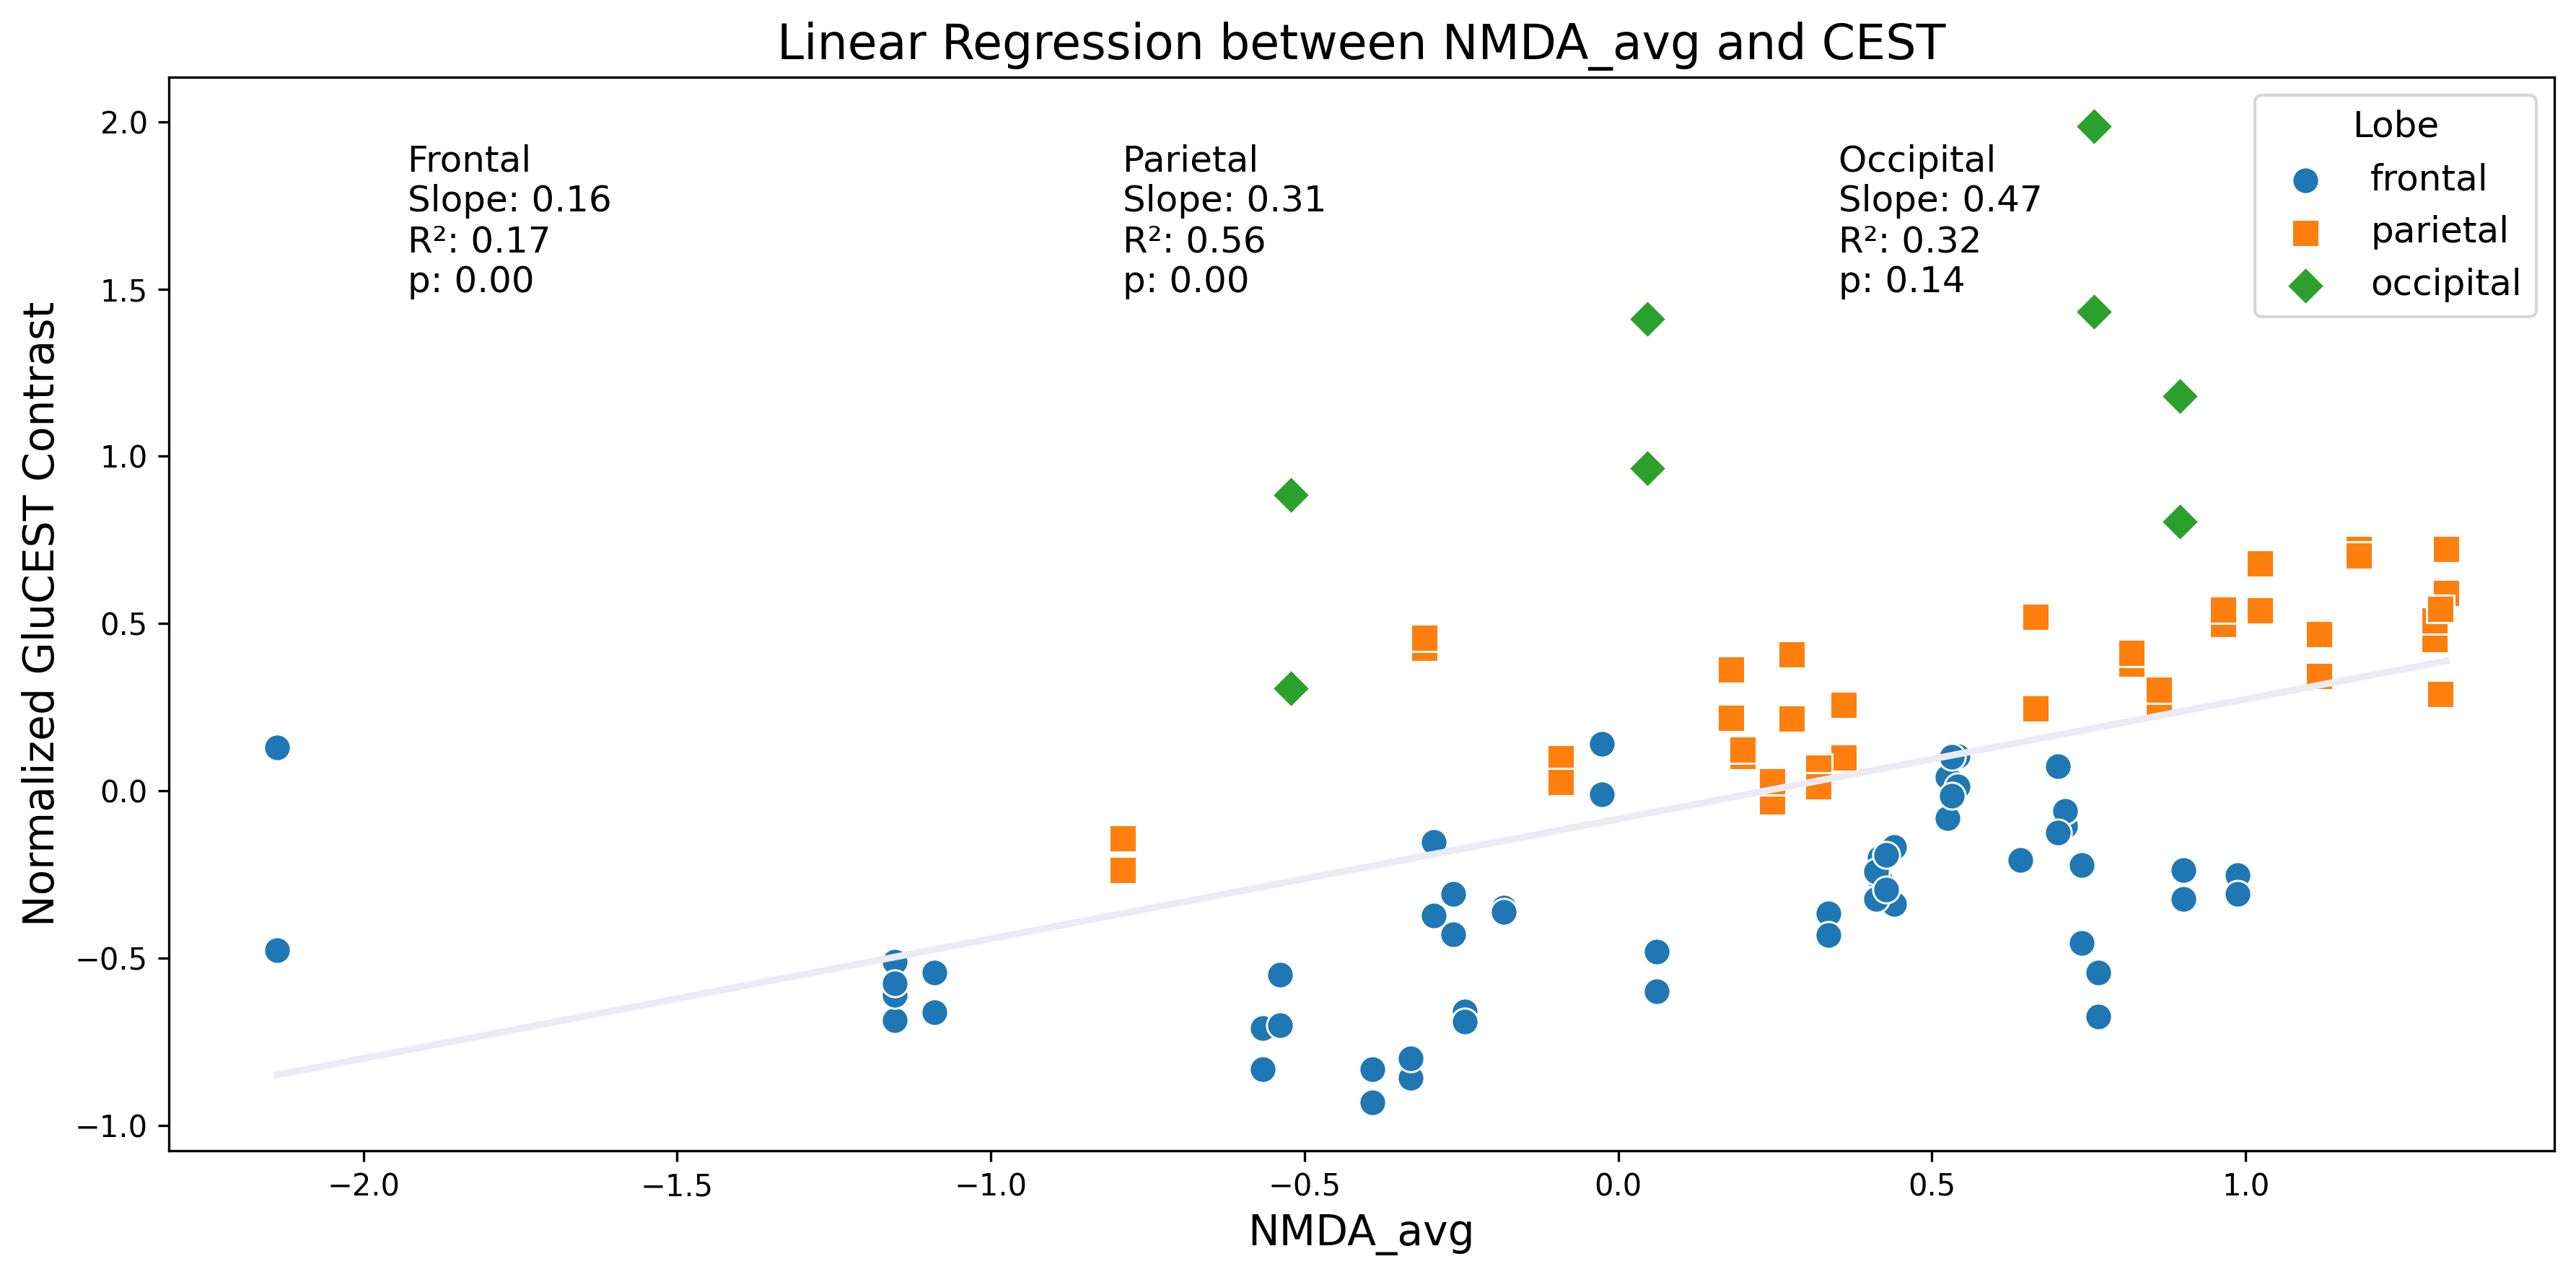

mGluR5_avg


/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_14437/4084737229.py:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_14437/4084737229.py:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_14437/4084737229.py:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


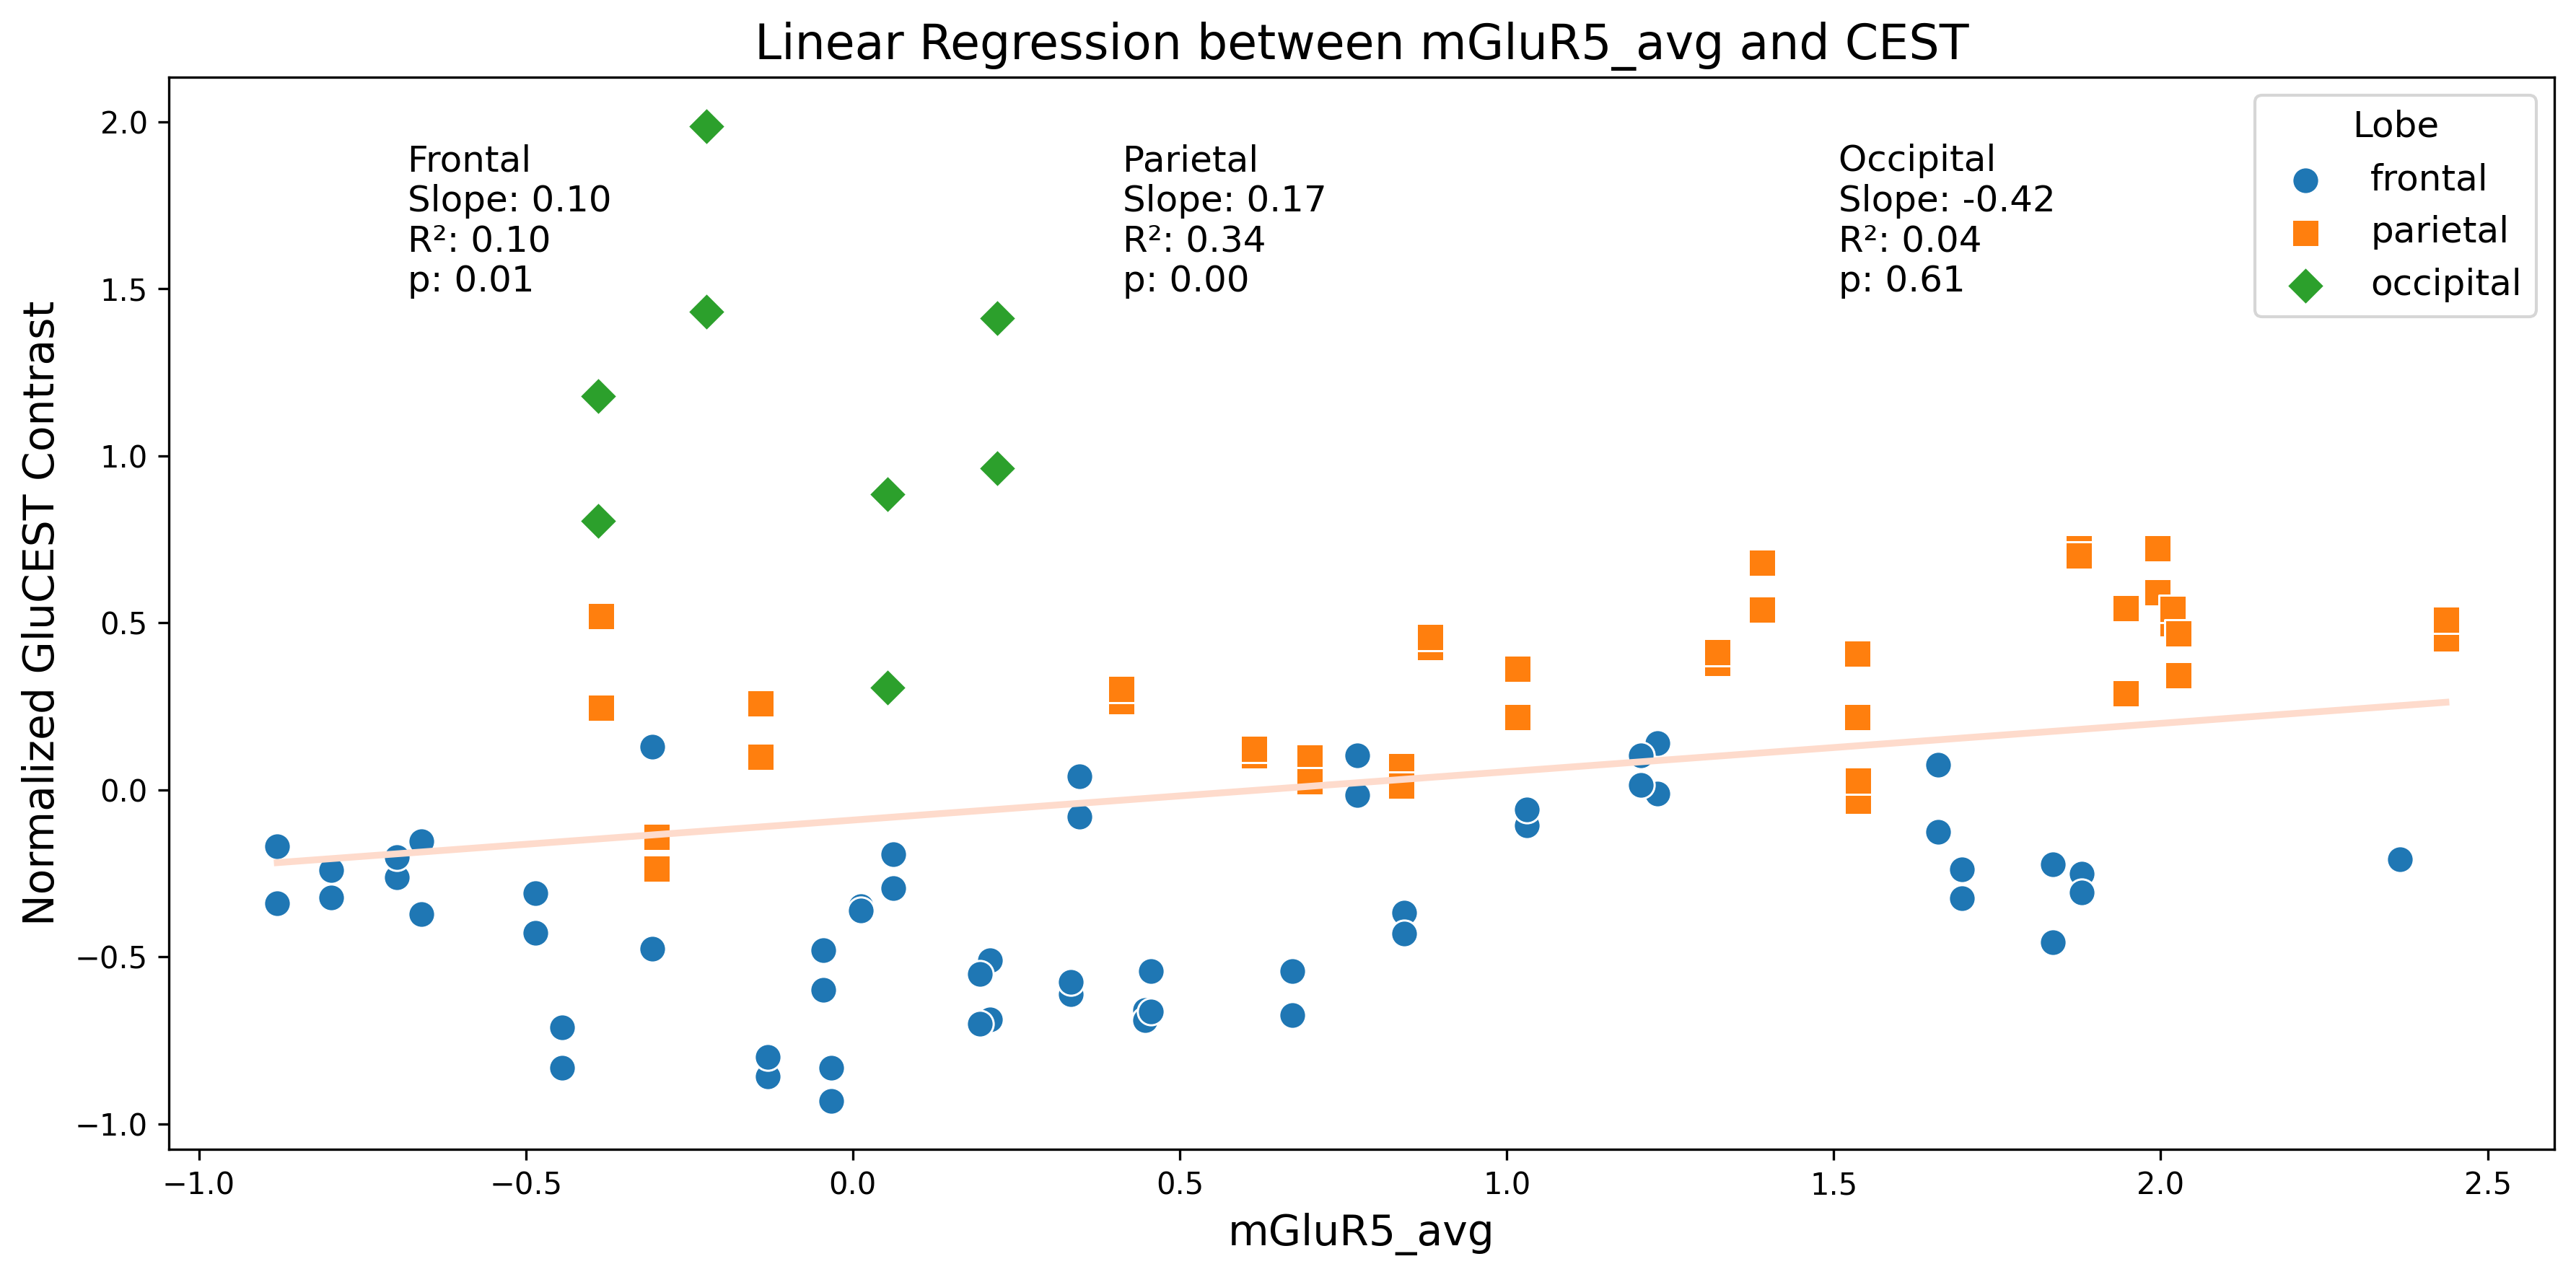

GABA_avg


/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_14437/4084737229.py:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_14437/4084737229.py:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/kk/w6xmtt2d55xfbxvb6wcqhq580000gp/T/ipykernel_14437/4084737229.py:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


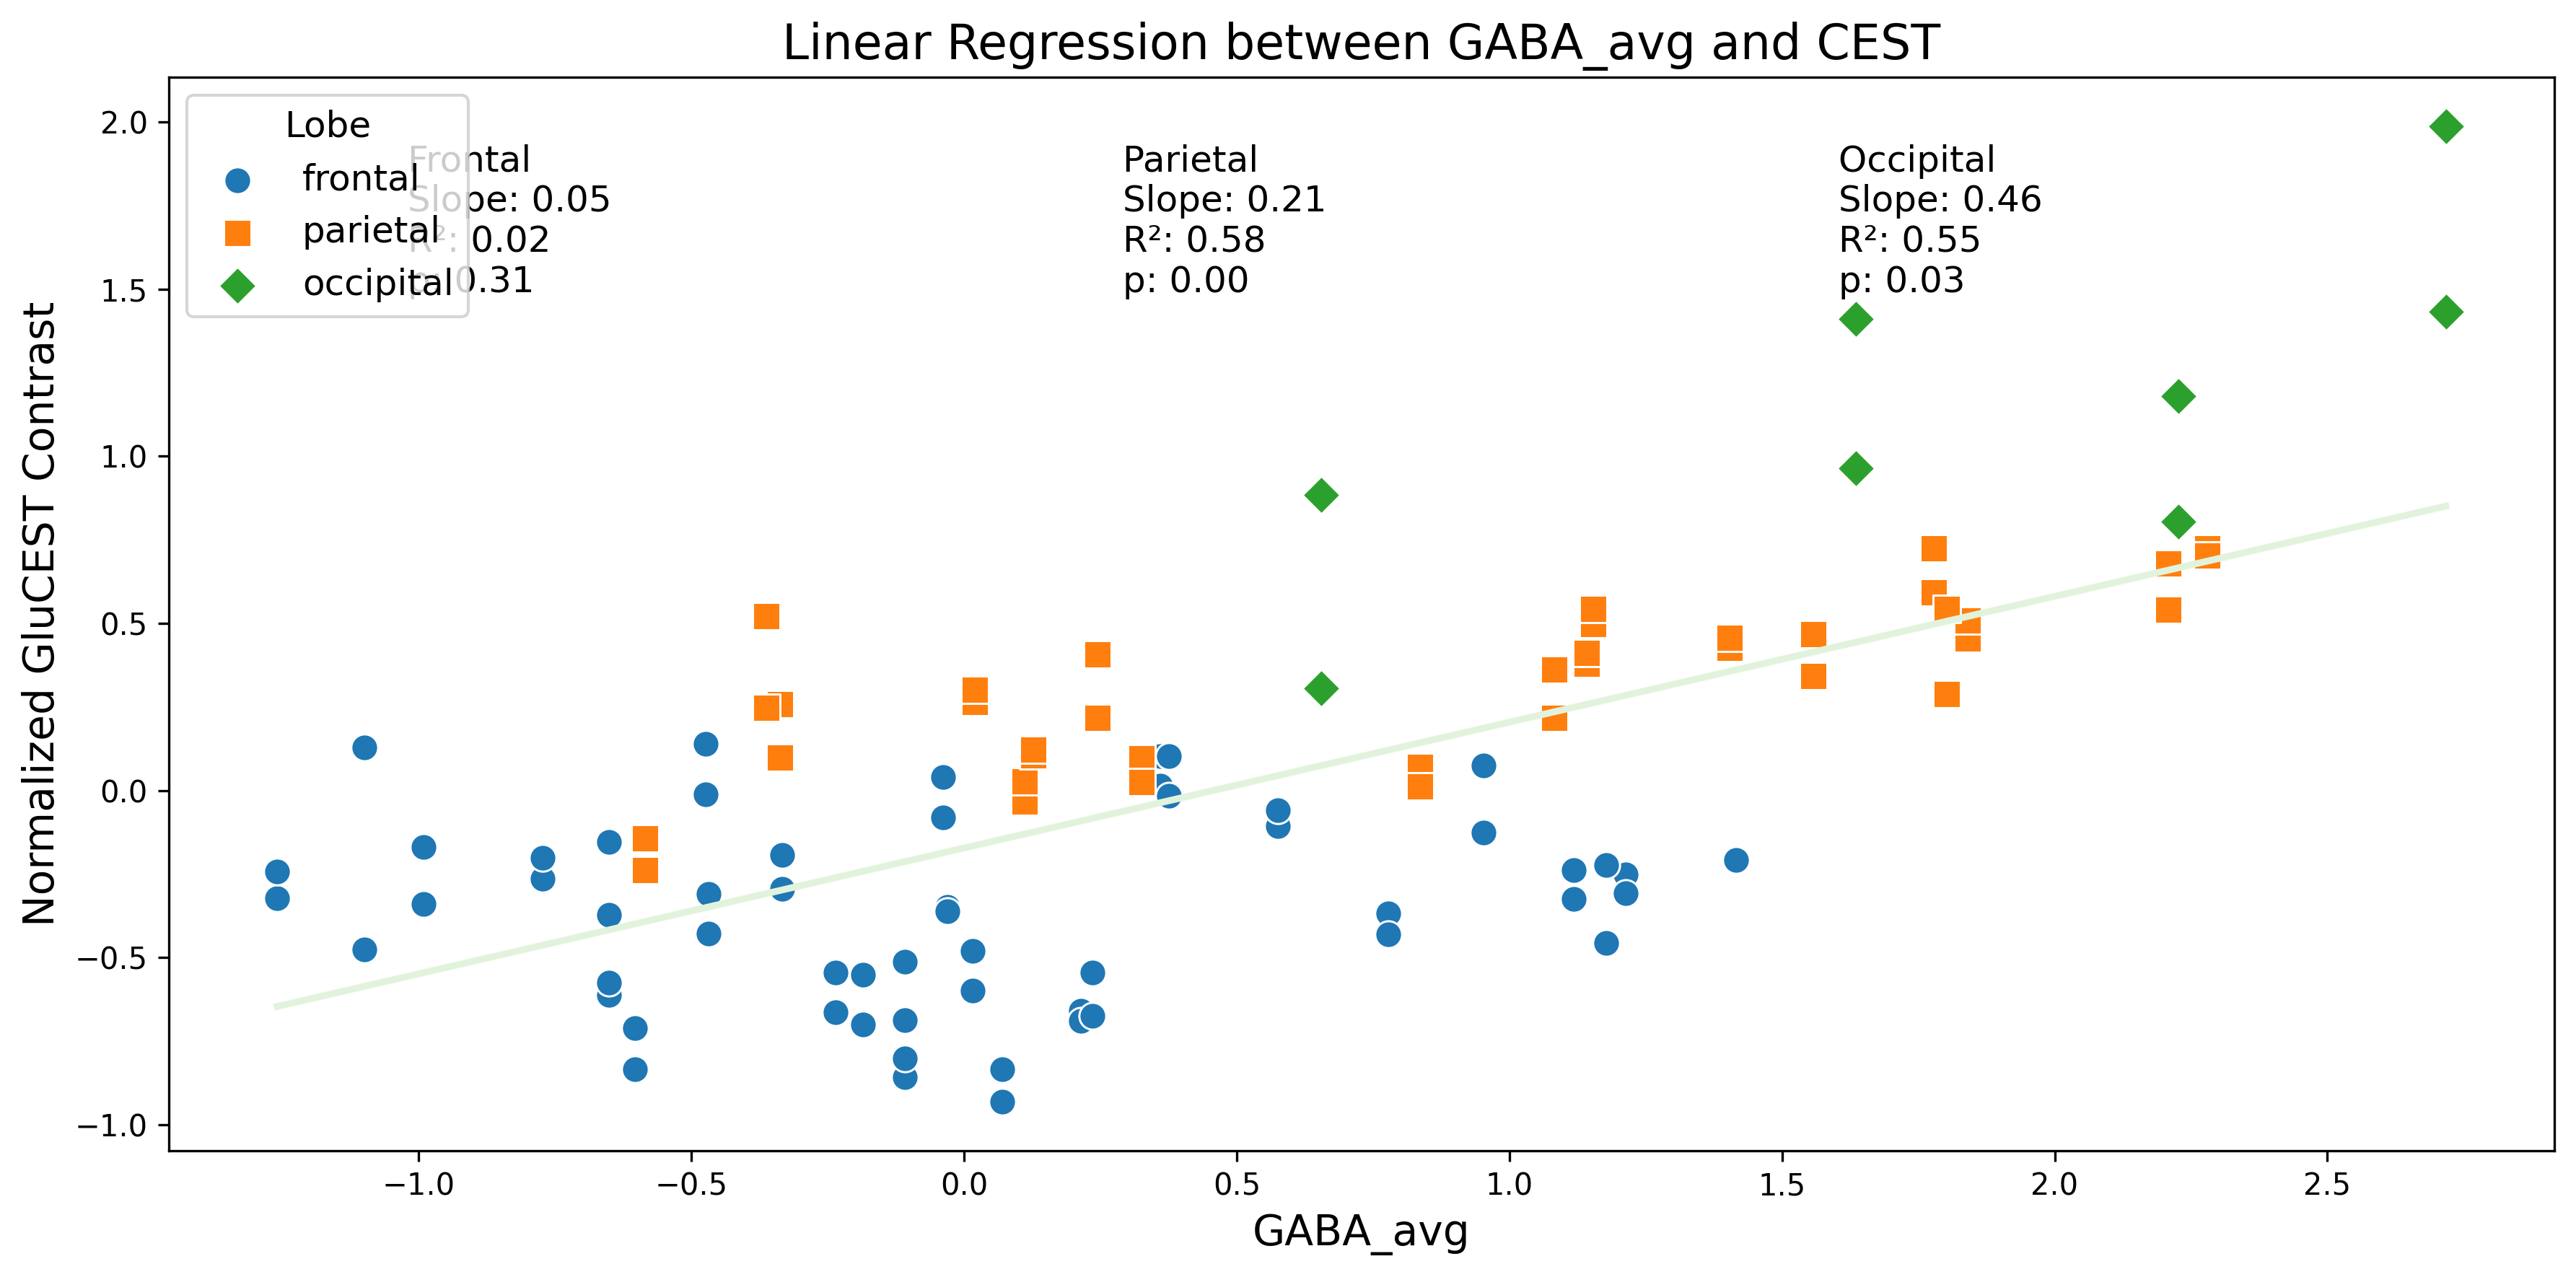

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Define palette and shapes
nmap_palette = {
    "NMDA_avg": "Purples",
    "mGluR5_avg": "Reds",
    "GABA_avg": "Greens",
    "D2": "Oranges"
}

lobe_shapes = {
    "frontal": "o",
    "parietal": "s",
    "occipital": "D"
}

# Loop through nmaps to create plots
for nmap in nmaps:
    print(nmap)

    # Prepare the data for plotting
    graph_df = means_df
    palette = nmap_palette.get(nmap, "Set1")  # Default to Set1 if not found

    # Set up the figure with a wide aspect ratio and high DPI
    plt.figure(figsize=(12, 6), dpi=300)

    # Plot the scatter plot with lobe-specific markers
    for lobe, marker in lobe_shapes.items():
        subset = graph_df[graph_df['Lobe'] == lobe]
        sns.scatterplot(
            x=nmap, y='CEST_avg', data=subset, 
            marker=marker, label=lobe, palette=palette, s=80
        )

    # Add the regression line
    sns.regplot(
        x=nmap, y='CEST_avg', data=graph_df, scatter=False, 
        color=sns.color_palette(palette)[0], ci=None  # Use first palette color
    )

    # Set labels and title with larger font sizes
    plt.xlabel(nmap, fontsize=14)
    plt.ylabel("Normalized GluCEST Contrast", fontsize=14)
    plt.title(f'Linear Regression between {nmap} and CEST', fontsize=16)
    
    # Calculate and display regression statistics for each lobe
    for idx, lobe in enumerate(lobe_shapes.keys()):
        subset = graph_df[graph_df['Lobe'] == lobe]
        slope, intercept, r_value, p_value, std_err = linregress(subset[nmap], subset['CEST_avg'])
        plt.text(
            0.1 + idx * 0.3, 0.8, 
            f'{lobe.capitalize()} \nSlope: {slope:.2f}\nR²: {r_value**2:.2f}\np: {p_value:.2f}', 
            transform=plt.gca().transAxes, fontsize=12
        )

    # Customize legend
    plt.legend(title='Lobe', title_fontsize=12, fontsize=12)

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

                         Parcel hstatus  CEST_avg  NMDA_avg  mGluR5_avg  \
0    caudalanteriorcingulate_5R      HC  0.140048 -0.026330    1.229935   
1    caudalanteriorcingulate_5R     PSY -0.011085 -0.026330    1.229935   
2                     cuneus_3R      HC  0.884299 -0.522157    0.053661   
3                     cuneus_3R     PSY  0.305783 -0.522157    0.053661   
4                     cuneus_5R      HC  1.411665  0.046650    0.220775   
..                          ...     ...       ...       ...         ...   
99           superiorfrontal_7R     PSY -0.455633  0.739121    1.834678   
100          superiorfrontal_8R      HC -0.857712 -0.331275   -0.129873   
101          superiorfrontal_8R     PSY -0.800876 -0.331275   -0.129873   
102          superiorfrontal_9R      HC -0.154002 -0.293822   -0.660154   
103          superiorfrontal_9R     PSY -0.372532 -0.293822   -0.660154   

     GABA_avg       Lobe  
0   -0.473436    frontal  
1   -0.473436    frontal  
2    0.654213  occ

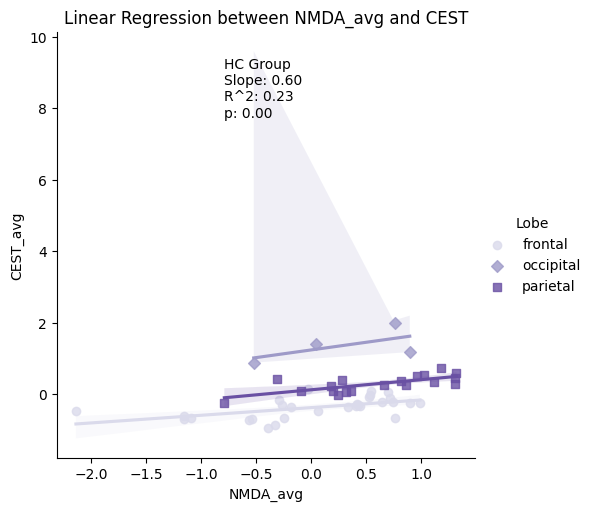

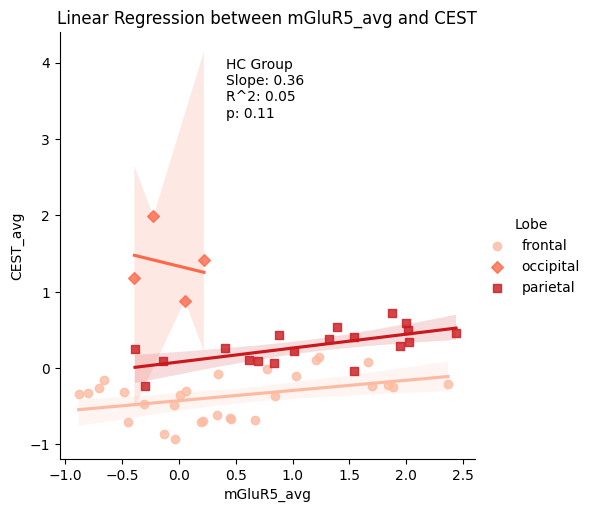

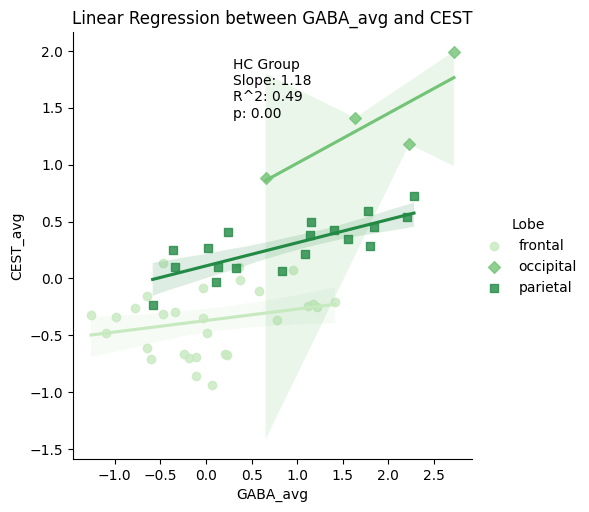

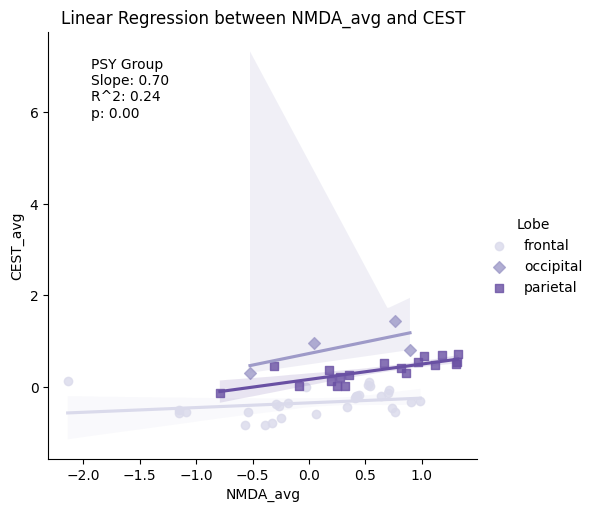

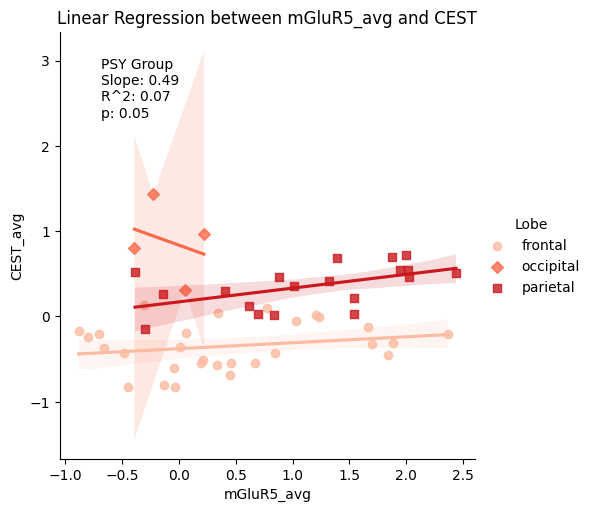

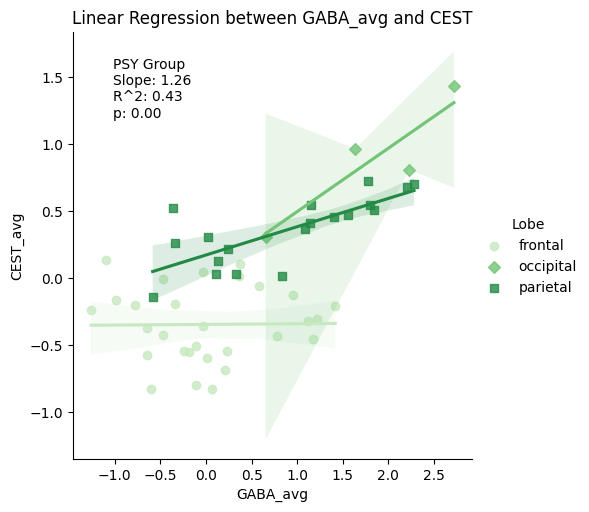

In [7]:
print(means_df)
nmap_palette = {
    "NMDA_avg": "Purples",   # Replace with actual nmap names and desired palettes
    "mGluR5_avg": "Reds",
    "GABA_avg": "Greens",
    "D2": "Oranges"
    # Add more mappings as needed
}

lobe_shapes = {
    "frontal": "o",   # Replace with actual nmap names and desired palettes
    "parietal": "s",
    "occipital": "D"
    # Add more mappings as needed
}

for nmap in nmaps:
    #means_df[nmap] = pd.to_numeric(means_df[nmap], errors='coerce')
    #means_df['CEST_avg'] = pd.to_numeric(means_df['CEST_avg'], errors='coerce')
    graph_df = means_df  #.dropna(subset=[nmap, 'CEST_avg'])
    graph_df = graph_df[graph_df["hstatus"]=="HC"]
    palette = nmap_palette.get(nmap) # Default to "Set1" if nmap not in dictionary

    unique_shapes = graph_df['Lobe'].unique()
    markers_list = [lobe_shapes[shape] for shape in unique_shapes]

    plot = sns.lmplot(x=nmap, y='CEST_avg', hue='Lobe', data=graph_df, markers=markers_list, palette=palette)
    
    plt.xlabel(nmap)
    plt.ylabel("CEST_avg")
    plt.title('Linear Regression between ' + nmap + ' and CEST')
    
    #slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'PSY', 'CEST_avg'], graph_df.loc[graph_df['hstatus'] == 'PSY', nmap])
    #plt.text(0.1, 0.8, f'PSY Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'HC', 'CEST_avg'], graph_df.loc[graph_df['hstatus'] == 'HC', nmap])
    plt.text(0.4, 0.8, f'HC Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    #slope, intercept, r_value, p_value, std_err = linregress(graph_df['CEST_avg'], graph_df[nmap])
    #xplt.text(0.7, 0.8, f'All Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)

    plt.show() 

for nmap in nmaps:
    #means_df[nmap] = pd.to_numeric(means_df[nmap], errors='coerce')
    #means_df['CEST_avg'] = pd.to_numeric(means_df['CEST_avg'], errors='coerce')
    graph_df = means_df  #.dropna(subset=[nmap, 'CEST_avg'])
    graph_df = graph_df[graph_df["hstatus"]=="PSY"]
    palette = nmap_palette.get(nmap) # Default to "Set1" if nmap not in dictionary

    unique_shapes = graph_df['Lobe'].unique()
    markers_list = [lobe_shapes[shape] for shape in unique_shapes]

    plot = sns.lmplot(x=nmap, y='CEST_avg', hue='Lobe', data=graph_df, markers=markers_list, palette=palette)
    
    plt.xlabel(nmap)
    plt.ylabel("CEST_avg")
    plt.title('Linear Regression between ' + nmap + ' and CEST')
    
    slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'PSY', 'CEST_avg'], graph_df.loc[graph_df['hstatus'] == 'PSY', nmap])
    plt.text(0.1, 0.8, f'PSY Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    #slope, intercept, r_value, p_value, std_err = linregress(graph_df.loc[graph_df['hstatus'] == 'HC', 'CEST_avg'], graph_df.loc[graph_df['hstatus'] == 'HC', nmap])
    #plt.text(0.4, 0.8, f'HC Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)
    #slope, intercept, r_value, p_value, std_err = linregress(graph_df['CEST_avg'], graph_df[nmap])
    #xplt.text(0.7, 0.8, f'All Group\nSlope: {slope:.2f}\nR^2: {r_value**2:.2f}\np: {p_value:.2f}', transform=plt.gca().transAxes)

    plt.show() 

In [8]:

df_encoded = pd.get_dummies(means_df, columns=['hstatus', 'Lobe'], drop_first=True)
df_encoded = df_encoded.drop(['Parcel', 'mGluR5_avg', 'GABA_avg'], axis=1)
df_encoded['hstatus_PSY'] = df_encoded['hstatus_PSY'].astype(int)
df_encoded['Lobe_parietal'] = df_encoded['Lobe_parietal'].astype(int)
df_encoded['Lobe_occipital'] = df_encoded['Lobe_occipital'].astype(int)
df_encoded = df_encoded.drop(['Lobe_occipital', 'Lobe_parietal'], axis=1) #remove later
print(df_encoded)

import statsmodels.api as sm

# Define the target (y) and predictors (X)
#X = df_encoded[['NMDA_avg', 'hstatus_PSY', 'Lobe_occipital']]
X = df_encoded[['NMDA_avg', 'hstatus_PSY']]
y = df_encoded['CEST_avg']

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Print the model summary
print(model.summary())


     CEST_avg  NMDA_avg  hstatus_PSY
0    0.140048 -0.026330            0
1   -0.011085 -0.026330            1
2    0.884299 -0.522157            0
3    0.305783 -0.522157            1
4    1.411665  0.046650            0
..        ...       ...          ...
99  -0.455633  0.739121            1
100 -0.857712 -0.331275            0
101 -0.800876 -0.331275            1
102 -0.154002 -0.293822            0
103 -0.372532 -0.293822            1

[104 rows x 3 columns]
                            OLS Regression Results                            
Dep. Variable:               CEST_avg   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     15.07
Date:                Thu, 17 Oct 2024   Prob (F-statistic):           1.87e-06
Time:                        09:48:12   Log-Likelihood:                -69.150
No. Observations:                 104   AIC:              

In [9]:
schaefer_nifti = nib.load('/Users/pecsok/projects/Neuromaps/pecsok_pfns/neuromaps/data/test_masks/Schaefer2018_1000Parcels_17Networks_order_FSLMNI152_1mm.nii.gz')
schaefer_data = schaefer_nifti.get_fdata()

# CEST DATA
datapath = '/Users/pecsok/projects/Neuromaps/hansen_receptors/'
figpath = '/Users/pecsok/projects/GluCEST-fMRI/glucest-rsfmri/fmri_pipeline/parcellated_pipeline/figures'
cestavg_df = pd.DataFrame(index=range(1, 1001), columns=['CESTavg'])
cestavg_df['CESTavg'] = np.nan  # Initialize all values to 0
for _, row in cestdf.iterrows():
    # Extract parcel ID number using regex
    match = re.search(r'(\d+)', row['parcel'])
    if match:
        parcel_id = int(match.group(1))
        # Add CESTavg data to corresponding row in the new DataFrame
        if 1 <= parcel_id <= 1000:  # Ensure the parcel ID is within range
            cestavg_df.at[parcel_id, 'CESTavg'] = row['CESTavg']
            
for i, row in cestavg_df.iterrows():
    parcel_id = i
    value = row['CESTavg']
print(cestavg_df)

    
parcel_values = pd.DataFrame({
    'parcel_id': range(1, 1001),  # Parcel IDs should range from 1 to 1000
    'value': cestavg_df['CESTavg'] # np.random.rand(1000)  # Replace with your actual values
})
print(parcel_values)


# Create a copy of the Schaefer atlas array to modify
new_schaefer_data = np.zeros(schaefer_data.shape)

# Loop through each parcel and assign the corresponding value from your DataFrame
for i, row in parcel_values.iterrows():
    parcel_id = row['parcel_id']
    value = row['value']
    
    # Assign the value to all voxels belonging to the current parcel ID
    new_schaefer_data[schaefer_data == parcel_id] = value

# Create a new NIfTI image with the updated data
new_nifti = nib.Nifti1Image(new_schaefer_data, affine=schaefer_nifti.affine, header=schaefer_nifti.header)

# Save the new NIfTI file
new_nifti.to_filename('updated_schaefer_atlas.nii.gz')

NameError: name 'nib' is not defined